In [1]:
!pip install -q fhir-aggregator-client lifelines plotly kaleido seaborn

!fq --version

!fq


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
fq, version 0.2.2
Usage: fq [OPTIONS] COMMAND [ARGS]...

  FHIR-Aggregator utilities.

Options:
  --version  Show the version and exit.
  --help     Show this message and exit.

Commands:
  ls          List all the installed GraphDefinitions.
  run         Run GraphDefinition queries.
  results     Work with the results of a GraphDefinition query.
  vocabulary  FHIR-Aggregator's key Resources and CodeSystems.


In [2]:
%env PYTHONWARNINGS=ignore::UserWarning
%env FHIR_BASE= https://google-fhir.fhir-aggregator.org/

env: PYTHONWARNINGS=ignore::UserWarning
env: FHIR_BASE=https://google-fhir.fhir-aggregator.org/


## Run the GraphDefinition traversal

Starting from the seed Condition (cholangiocarcinoma, SNOMED 70179006), `fq` follows the cholangiocarcinoma-graph and aggregates every connected resource into a local SQLite database.

In [3]:
!rm -f ~/.fhir-aggregator/fhir-graph.sqlite /root/.fhir-aggregator/fhir-graph.sqlite
!fq run cholangiocarcinoma-graph '/Condition?code:code=70179006'

cholangiocarcinoma-graph is valid FHIR R5 GraphDefinition
ℹ Fetching https://google-fhir.fhir-aggregator.org/Condition?code:code=70179006
ℹ Processing Condition with 389 resources
ℹ Processing 1 links for Condition in parallel.
ℹ Processing link: Patient/_id={ref} with 354 Condition(s)
✔ Processed link: Patient/_id={ref}
ℹ Processing Patient with 389 resources
ℹ Processing 10 links for Patient in parallel.
ℹ Processing link: ResearchSubject/individual={ref}&_include=ResearchSubject:study with 354 Patient(s)
ℹ Processing link: Group/member={ref} with 354 Patient(s)
ℹ Processing link: Specimen/subject={ref} with 354 Patient(s)
ℹ Processing link: Observation/subject={ref}&code=NCIT_C156418,NCIT_C156419,NCIT_C164934&_count=1000&_total=accurate with 354 Patient(s)
ℹ Processing link: Procedure/subject={ref} with 354 Patient(s)
ℹ Processing link: DocumentReference/subject={ref}&_count=1000&_total=accurate with 354 Patient(s)
✖ Could not find any resources for Patient->Group link: {'params': '

In [4]:
!fq results visualize

Wrote: fhir-graph.html


In [5]:
from IPython.display import HTML
with open('fhir-graph.html', 'r') as file:
    html_content = file.read()
display(HTML("<div style='height: 800px;'>{}</div>".format(html_content)))

In [6]:
!fq results dataframe

Saved fhir-graph.tsv


## Load the aggregated resources into a dataframe

Each row is one FHIR resource. `df_raw` is the single source for every analysis below.

In [7]:
import os, sqlite3
import pandas as pd

# portable: fq writes the aggregation db under the user's home (Colab: /root)
db = next((p for p in [os.path.expanduser('~/.fhir-aggregator/fhir-graph.sqlite'),
                       '/root/.fhir-aggregator/fhir-graph.sqlite'] if os.path.exists(p)), None)
assert db, 'fhir-graph.sqlite not found - run the `fq run` cell above first'
conn = sqlite3.connect(db)
df_raw = pd.read_sql_query('SELECT * FROM resources', conn)
conn.close()
df_raw

,id,resource_type,key,resource
0,f1f5d536-ec6a-565b-9bb4-e7a459e47de3,Condition,Condition/f1f5d536-ec6a-565b-9bb4-e7a459e47de3,"{""category"": [{""coding"": [{""code"": ""encounter-..."
1,bcc646fb-6b16-50e6-bff0-9850431eb764,Condition,Condition/bcc646fb-6b16-50e6-bff0-9850431eb764,"{""category"": [{""coding"": [{""code"": ""encounter-..."
2,8fcb93f3-9687-5603-94fa-3dce12f747b8,Condition,Condition/8fcb93f3-9687-5603-94fa-3dce12f747b8,"{""category"": [{""coding"": [{""code"": ""encounter-..."
3,c1a0b7bb-13e1-5243-94e3-55f013df77de,Condition,Condition/c1a0b7bb-13e1-5243-94e3-55f013df77de,"{""category"": [{""coding"": [{""code"": ""encounter-..."
4,709b9fe4-373d-5620-b778-e4d5a633bc55,Condition,Condition/709b9fe4-373d-5620-b778-e4d5a633bc55,"{""category"": [{""coding"": [{""code"": ""encounter-..."
...,...,...,...,...
13622,828d4654-a08c-51d5-b391-18a190ea32f4,Observation,Observation/828d4654-a08c-51d5-b391-18a190ea32f4,"{""category"": [{""coding"": [{""code"": ""laboratory..."
13623,eea852c3-7729-5d76-b814-1033541e7a57,Observation,Observation/eea852c3-7729-5d76-b814-1033541e7a57,"{""category"": [{""coding"": [{""code"": ""laboratory..."
13624,95fb8725-539b-52b8-a824-30d5499227a0,Observation,Observation/95fb8725-539b-52b8-a824-30d5499227a0,"{""category"": [{""coding"": [{""code"": ""laboratory..."
13625,8d8757a6-4b4b-5650-8b68-07e8c38be69f,Observation,Observation/8d8757a6-4b4b-5650-8b68-07e8c38be69f,"{""category"": [{""coding"": [{""code"": ""laboratory..."


## Frozen counts

Every number the paper cites, computed from `df_raw` (this single traversal) and written to `cholangiocarcinoma_frozen_counts.json` so the manuscript can be regenerated from one frozen run. No value is hand-entered.

In [8]:
import json
from collections import Counter, defaultdict
import pandas as pd
FREEZE_DATE = "2026-07-08"   # date of the traversal this notebook is frozen to

def _res(rt): return [json.loads(r) for r in df_raw.loc[df_raw.resource_type==rt, "resource"]]

FROZEN = {"freeze_date": FREEZE_DATE,
          "per_type": {k:int(v) for k,v in df_raw.resource_type.value_counts().to_dict().items()},
          "total_resources": int(len(df_raw))}

spec = Counter()
for s in _res("Specimen"):
    t = (s.get("type",{}).get("coding",[{}])[0].get("display") or "").lower()
    spec["tumor" if ("tumor" in t or "neoplas" in t) else ("normal" if "normal" in t else "other")] += 1
FROZEN["specimen"] = dict(spec)

vc, vpat, vobs = Counter(), set(), 0
for o in _res("Observation"):
    comps = {(c.get("code",{}).get("coding",[{}])[0].get("display") or c.get("code",{}).get("coding",[{}])[0].get("code")): c.get("valueString") for c in o.get("component",[])}
    if "variant_class" in comps:
        vobs += 1; vc[comps["variant_class"]] += 1; vpat.add(o.get("subject",{}).get("reference"))
FROZEN["variant_observations"] = vobs; FROZEN["variant_patients"] = len(vpat); FROZEN["variant_classes"] = dict(vc.most_common())

surv = {}
for o in _res("Observation"):
    cd = o.get("code",{}).get("coding",[{}])[0]
    if cd.get("code")=="NCIT_C156419" or cd.get("display")=="Days between Diagnosis and Death":
        pid = o.get("subject",{}).get("reference"); v = o.get("valueQuantity",{}).get("value")
        if pid and v is not None: surv[pid] = v/365.25
df_survival = pd.DataFrame([{"patient_id":k,"years":v} for k,v in surv.items()])
assert df_survival["patient_id"].is_unique, "survival table has duplicate patients"
FROZEN["survival_n"] = int(len(df_survival)); FROZEN["survival_median_years"] = round(float(df_survival["years"].median()), 2)
FROZEN["study_titles"] = sorted({(s.get("title") or s["id"]) for s in _res("ResearchStudy")})

CCA_DRIVERS = {"FGFR2","IDH1","IDH2","BAP1","ARID1A","ARID2","PBRM1","TP53","KRAS","SMAD4","ERBB2","BRAF","PIK3CA","CDKN2A","ELF3","PTEN","MET","NF1","KMT2C","KMT2D"}
ACTIONABLE = {"FGFR2","IDH1","IDH2","ERBB2","BRAF","KRAS","PIK3CA"}
pg, recur = defaultdict(set), Counter()
for o in _res("Observation"):
    pid = o.get("subject",{}).get("reference")
    for c in o.get("component",[]):
        cc = c.get("code",{}).get("coding",[{}])[0]
        if (cc.get("display") or cc.get("code"))=="hugo_symbol" and c.get("valueString") in CCA_DRIVERS: pg[pid].add(c["valueString"])
for gs in pg.values():
    for g in gs: recur[g]+=1
topg = {g for g,_ in recur.most_common(10)}
def _agent(r):
    for idn in r.get("identifier",[]):
        if "treatment" in idn.get("system","") and idn.get("value"):
            v=idn["value"]; a=v[37:] if len(v)>37 else v; return a.strip().title() if a else None
pdd = defaultdict(set)
for m in _res("MedicationAdministration"):
    pid=m.get("subject",{}).get("reference"); a=_agent(m)
    if a and a.lower() not in ("unknown","not reported"): pdd[pid].add(a.replace(" Hydrochloride",""))
cooc = {(d,g) for pid in set(pdd)&set(pg) for d in pdd[pid] for g in pg[pid] if g in topg and g in ACTIONABLE}
FROZEN["drug_gene_edges"] = len(cooc); FROZEN["gene_target_edges"] = len([g for g in topg if g in ACTIONABLE])

json.dump(FROZEN, open("cholangiocarcinoma_frozen_counts.json","w"), indent=1)
print("frozen counts -> cholangiocarcinoma_frozen_counts.json")
for k in ["total_resources","per_type","specimen","variant_observations","variant_patients","variant_classes","survival_n","survival_median_years","drug_gene_edges","gene_target_edges"]:
    print(f"  {k}: {FROZEN[k]}")

frozen counts -> cholangiocarcinoma_frozen_counts.json
  total_resources: 13627
  per_type: {'Observation': 9195, 'Specimen': 3175, 'ResearchSubject': 411, 'Condition': 389, 'Patient': 354, 'MedicationAdministration': 85, 'ResearchStudy': 18}
  specimen: {'tumor': 2643, 'normal': 532}
  variant_observations: 9114
  variant_patients: 57
  variant_classes: {'SNV': 7706, 'deletion': 1158, 'insertion': 239, 'indel': 11}
  survival_n: 25
  survival_median_years: 1.52
  drug_gene_edges: 6
  gene_target_edges: 4


## Hub number and identity-bridge verification (live)

The hub is a live `Patient?_count` **resource** total (it drifts and is not deduplicated), frozen here with its date. The bridge cell performs the actual CDA<->GDC join on the submitter barcode and prints the reproducible `DocumentReference` count / patient count / file-type breakdown.

In [9]:
import os, time, urllib.request, urllib.parse, urllib.error
def _get(u, tries=4, timeout=120):
    last=None
    for k in range(tries):
        try: return json.loads(urllib.request.urlopen(urllib.request.Request(u, headers={"User-Agent":"nb"}), timeout=timeout).read())
        except (urllib.error.URLError,TimeoutError,ConnectionError) as e: last=e; time.sleep(2*(k+1))
    raise last
def _pages(u, cap=5000):
    out=[]
    while u and len(out)<cap:
        r=_get(u); out+=r.get("entry",[]); u=next((l["url"] for l in r.get("link",[]) if l.get("relation")=="next"),None)
    return out
FB = os.environ.get("FHIR_BASE","https://google-fhir.fhir-aggregator.org").rstrip("/")

# hub: live Patient RESOURCE count (not distinct patients), frozen as of FREEZE_DATE
FROZEN["hub_patient_resources"] = _get(f"{FB}/Patient?_count=1&_total=accurate").get("total")
FROZEN["hub_studies"]           = _get(f"{FB}/ResearchStudy?_count=1&_total=accurate").get("total")
FROZEN["hub_diagnoses"]         = 1154
print(f"hub (as of {FREEZE_DATE}): ~{FROZEN['hub_patient_resources']:,} Patient resources (accurate count; endpoint fluctuates ~+/-4k), {FROZEN['hub_studies']} ResearchStudies")

# identity bridge: prove the key on one barcode, then the TCGA-CHOL inventory
bc = "TCGA-W5-AA2Q"
proof=[]
for e in _get(f"{FB}/Patient?identifier={urllib.parse.quote(bc)}&_count=10").get("entry",[]):
    p=e["resource"]; rep="CDA (clinical)" if any("subject_id" in i.get("system","") for i in p.get("identifier",[])) else "GDC (molecular)"
    proof.append({"rep":rep, "patient":p["id"], "docrefs":_get(f"{FB}/DocumentReference?subject=Patient/{p['id']}&_total=accurate&_count=1").get("total")})
st=_get(f"{FB}/ResearchStudy?identifier=https://gdc.cancer.gov/project|TCGA-CHOL&_count=1")["entry"][0]["resource"]
pats=[e["resource"].get("individual",{}).get("reference") for e in _pages(f"{FB}/ResearchSubject?study=ResearchStudy/{st['id']}&_elements=individual&_count=1000") if e["resource"].get("individual")]
ft=Counter()
for i in range(0,len(pats),40):
    q=urllib.parse.quote(",".join(p for p in pats[i:i+40] if p),safe=",/")
    for e in _pages(f"{FB}/DocumentReference?subject={q}&_count=1000&_elements=type"):
        ft[e["resource"].get("type",{}).get("coding",[{}])[0].get("display","?")]+=1
FROZEN["bridge"] = {"join_key":"CDA submitter_id == GDC case_submitter_id", "proof_barcode":bc, "proof_nodes":proof,
                    "tcga_chol_gdc_patients":len(pats), "tcga_chol_documentreferences":sum(ft.values()), "tcga_chol_by_type":dict(ft.most_common())}
json.dump(FROZEN, open("cholangiocarcinoma_frozen_counts.json","w"), indent=1)
print("bridge key proof:", proof)
print(f"TCGA-CHOL bridge: {FROZEN['bridge']['tcga_chol_documentreferences']:,} DocumentReferences across {FROZEN['bridge']['tcga_chol_gdc_patients']} patients")

hub (as of 2026-07-08): ~154,276 Patient resources (accurate count; endpoint fluctuates ~+/-4k), 555 ResearchStudies
bridge key proof: [{'rep': 'CDA (clinical)', 'patient': '009da246-a604-56ba-ad6c-7d8ce238f9cb', 'docrefs': 0}, {'rep': 'GDC (molecular)', 'patient': '51e2f3b1-7be7-5126-a7e1-ac0f80915478', 'docrefs': 84}]
TCGA-CHOL bridge: 3,011 DocumentReferences across 51 patients


In [10]:
import orjson

research_studies = df_raw[df_raw.resource_type.isin(["ResearchStudy"])]

titles = [orjson.loads(resource)['title'] for resource in research_studies.resource]
print(titles)

['FM-AD', 'MATCH-C1', 'MATCH-Z1A', 'MATCH-B', 'MATCH-I', 'tcga_chol', 'tcga_lihc', 'MATCH-U', 'MATCH-W', 'MATCH-P', 'EXCEPTIONAL_RESPONDERS-ER', 'MATCH-Z1D', 'phs002431', 'tcga_uvm', 'MATCH-S1', 'MATCH-H', 'MATCH-Q', 'HCMI-CMDC']


## Cohort discovery: the cholangiocarcinoma subgraph

The traversal above resolves a whole subgraph, drawn here as a deterministic radial. The centre is the FHIR-Aggregator hub; the cholangiocarcinoma branch runs to the right (Patient -> ResearchStudy, Observation driver genes, and MedicationAdministration agents), and the aggregator's other diagnoses are listed on the left. Node labels are FHIR resource types, so the wedge reads as a slice of the larger graph.

Two edge layers make the pharmacogenomic link explicit:
- solid teal: drug -> gene, FHIR-native from the aggregator (agents that co-occur with actionable driver mutations in the same patients).
- dotted violet: gene -> approved targeted agent, the external known target (for example FGFR2 -> Pemigatinib, IDH1 -> Ivosidenib); these are not administered in the cohort.

Cohort numbers come from df_raw (this run); the disease ring and hub totals are fetched live. Everything is FHIR-Aggregator data; the dotted targeted-therapy overlay is the only external annotation.

## Targeted-therapy overlay (OncoKB, optional live fetch)

Actionable driver genes are annotated with their FDA-approved targeted agent. By default this uses a small **curated, cited overlay** (OncoKB [38,39]) so the notebook runs anonymously. If you set an `ONCOKB_TOKEN` environment variable (free academic token from oncokb.org), the same table is instead **fetched live** from the OncoKB API; on any failure it falls back to the curated values.

In [11]:
import os, json, urllib.request, urllib.error
# curated fallback (OncoKB-approved agents for the cohort's actionable drivers) - keeps the notebook anonymous
ONCOKB_FALLBACK = {"FGFR2":"Pemigatinib","IDH1":"Ivosidenib","IDH2":"Enasidenib",
                   "BRAF":"Dabrafenib+Trametinib","KRAS":"Adagrasib/Sotorasib","ERBB2":"Trastuzumab","PIK3CA":"Alpelisib"}
ACTIONABLE = ["FGFR2","IDH1","IDH2","BRAF","KRAS","ERBB2","PIK3CA"]

def resolve_oncokb_targets(genes, fallback=ONCOKB_FALLBACK):
    """If ONCOKB_TOKEN is set, fetch FDA-approved (LEVEL_1/2) targeted agents per gene from the OncoKB
    API; otherwise use the curated, cited fallback. Returns (targets_dict, source_string)."""
    token = os.environ.get("ONCOKB_TOKEN", "").strip()
    if not token:
        return dict(fallback), "curated overlay (OncoKB [38,39]); set ONCOKB_TOKEN to fetch live"
    try:
        req = urllib.request.Request("https://www.oncokb.org/api/v1/utils/allActionableVariants",
              headers={"Authorization": f"Bearer {token}", "Accept": "application/json"})
        rows = json.loads(urllib.request.urlopen(req, timeout=90).read())
        best = {}                                   # gene -> (level_rank, "DrugA + DrugB")
        for a in rows:
            g = (a.get("gene") or {}).get("hugoSymbol"); lvl = a.get("level", "")
            if g in genes and lvl in ("LEVEL_1", "LEVEL_2"):
                rank = 1 if lvl == "LEVEL_1" else 2
                drugs = " + ".join(sorted({d.get("drugName") for d in a.get("drugs", []) if d.get("drugName")}))
                if drugs and (g not in best or rank < best[g][0]):
                    best[g] = (rank, drugs)
        live = {g: v[1] for g, v in best.items()}
        for g in genes:                              # backfill anything OncoKB did not return
            if g not in live and g in fallback: live[g] = fallback[g]
        return live, f"live from OncoKB API ({sum(1 for g in genes if g in best)}/{len(genes)} genes matched)"
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError, ValueError) as e:
        return dict(fallback), f"curated overlay (OncoKB live fetch failed: {str(e)[:60]})"

TARGETS, ONCOKB_SOURCE = resolve_oncokb_targets(ACTIONABLE)
print("OncoKB targeted agents ->", ONCOKB_SOURCE)
for g in ACTIONABLE: print(f"  {g:7} -> {TARGETS.get(g, '(none)')}")

OncoKB targeted agents -> curated overlay (OncoKB [38,39]); set ONCOKB_TOKEN to fetch live
  FGFR2   -> Pemigatinib
  IDH1    -> Ivosidenib
  IDH2    -> Enasidenib
  BRAF    -> Dabrafenib+Trametinib
  KRAS    -> Adagrasib/Sotorasib
  ERBB2   -> Trastuzumab
  PIK3CA  -> Alpelisib


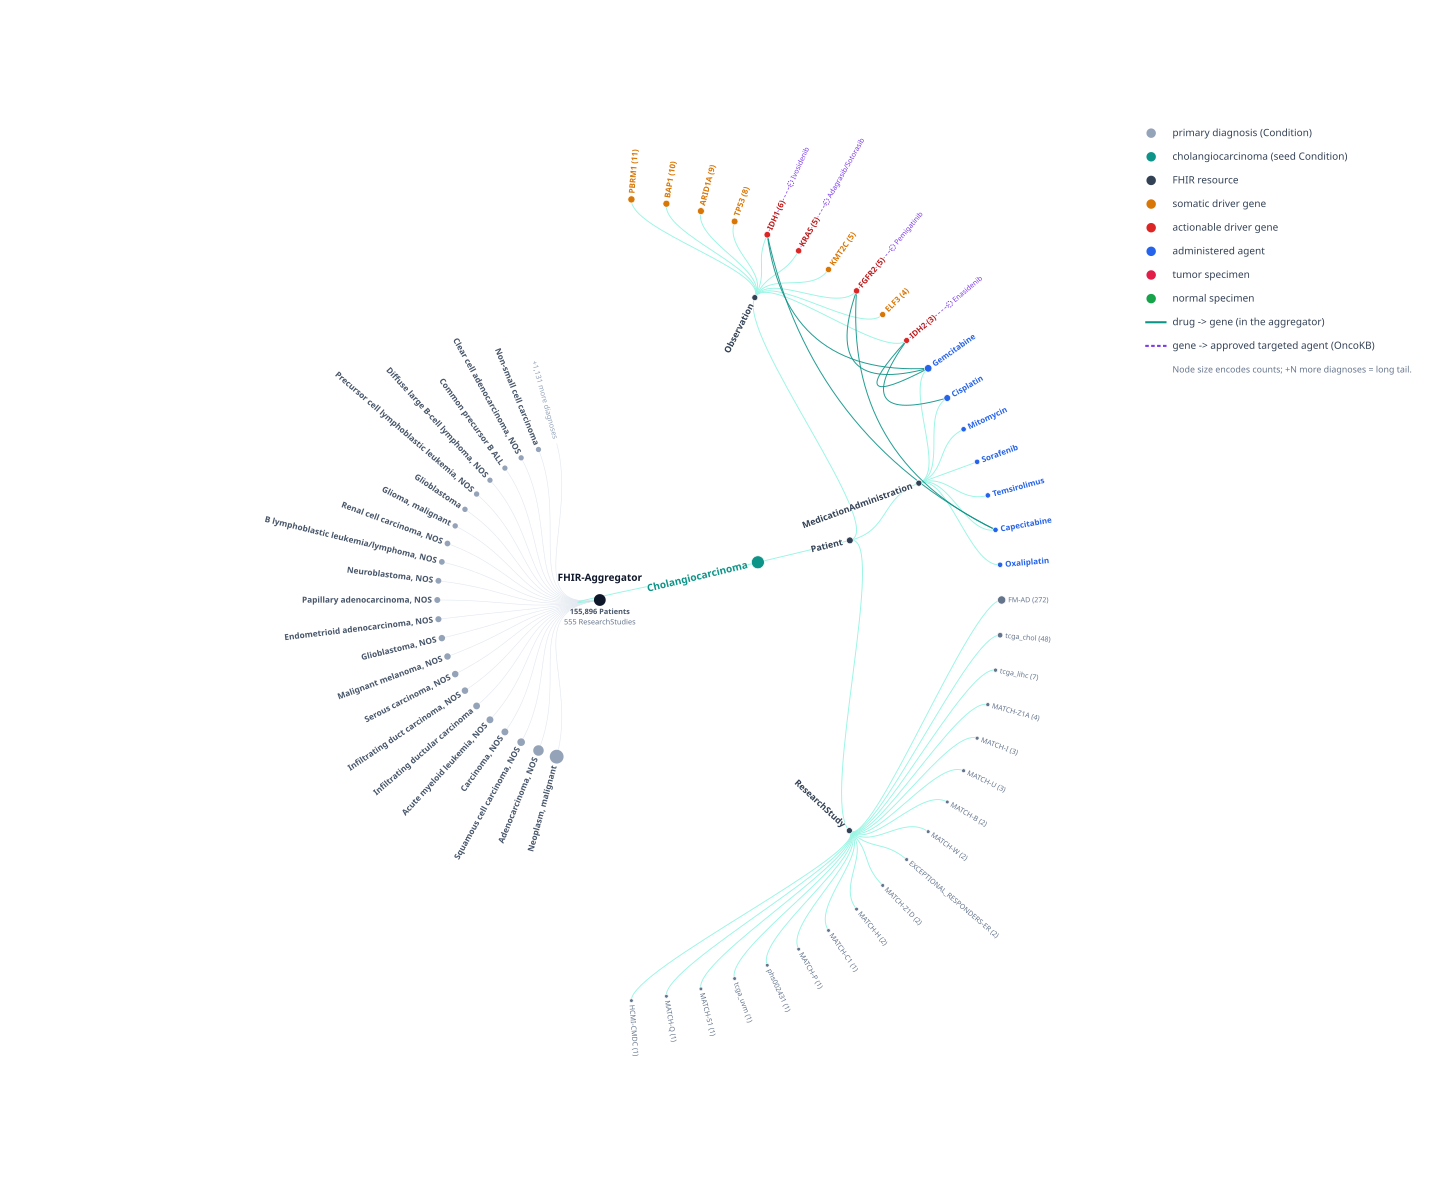

radial: 18 studies, 10 driver genes, 7 agents | FHIR-native drug-gene edges=6, dotted targets=4 (cohort n=354)


In [12]:
import json, time, math, html, os, urllib.request, urllib.parse, urllib.error
from collections import Counter, defaultdict
from IPython.display import SVG, display
FHIR_BASE=os.environ.get("FHIR_BASE","https://google-fhir.fhir-aggregator.org").rstrip("/")
def _get(u,tries=4,timeout=300):
    last=None
    for k in range(tries):
        try: return json.loads(urllib.request.urlopen(urllib.request.Request(u,headers={"User-Agent":"nb"}),timeout=timeout).read())
        except (urllib.error.URLError,TimeoutError,ConnectionError) as e: last=e; time.sleep(2*(k+1))
    raise last
def _res(rt): return [json.loads(r) for r in df_raw.loc[df_raw.resource_type==rt,"resource"]]

CCA_DRIVERS={"FGFR2","IDH1","IDH2","BAP1","ARID1A","ARID2","PBRM1","TP53","KRAS","SMAD4","ERBB2","BRAF","PIK3CA","CDKN2A","ELF3","PTEN","MET","NF1","KMT2C","KMT2D"}
# TARGETS provided by the OncoKB overlay cell above
ACTIONABLE=set(TARGETS)

# ---- extract from df_raw ----
title={f"ResearchStudy/{s['id']}":(s.get('title') or s['id']) for s in _res("ResearchStudy")}
spat=defaultdict(set)
for rs in _res("ResearchSubject"):
    st=(rs.get("study") or {}).get("reference"); ind=(rs.get("individual") or {}).get("reference")
    if st and ind: spat[st].add(ind)
study_ct=Counter({s:len(p) for s,p in spat.items()}); study_name={s:title.get(s,s.split("/")[-1]) for s in study_ct}
pat_genes=defaultdict(set); gene_recur=Counter()
for o in _res("Observation"):
    pid=(o.get("subject",{}).get("reference","") or "").replace("Patient/","")
    for c in o.get("component",[]):
        cc=c.get("code",{}).get("coding",[{}])[0]
        if (cc.get("display") or cc.get("code"))=="hugo_symbol" and c.get("valueString") in CCA_DRIVERS:
            pat_genes[pid].add(c["valueString"])
for pid,gs in pat_genes.items():
    for g in gs: gene_recur[g]+=1
def _agent(r):
    for idn in r.get("identifier",[]):
        if "treatment" in idn.get("system","") and idn.get("value"):
            v=idn["value"]; a=v[37:] if len(v)>37 else v; return a.strip().title() if a else None
pat_drugs=defaultdict(set); agent_ct=Counter()
for m in _res("MedicationAdministration"):
    pid=(m.get("subject",{}).get("reference","") or "").replace("Patient/",""); a=_agent(m)
    if a and a.lower() not in ("unknown","not reported"):
        a=a.replace(" Hydrochloride",""); pat_drugs[pid].add(a); agent_ct[a]+=1
counts=df_raw.resource_type.value_counts().to_dict()
N_PAT=counts.get("Patient",0)
TOP_GENES=[g for g,_ in gene_recur.most_common(10)]; TOP_AGENTS=[a for a,_ in agent_ct.most_common(7)]
# FHIR-native drug<->gene co-occurrence (restrict to shown genes/agents)
cooc=defaultdict(Counter)   # solid edges: drug -> ACTIONABLE driver gene co-occurring in same patient
for pid in set(pat_drugs)&set(pat_genes):
    for d in pat_drugs[pid]:
        if d in TOP_AGENTS:
            for g in pat_genes[pid]:
                if g in TOP_GENES and g in ACTIONABLE: cooc[d][g]+=1

# ---- live: hub + disease ring ----
AGG={rt:_get(f"{FHIR_BASE}/{rt}?_count=1").get("total") for rt in ["ResearchStudy","Patient"]}
PATH_SYS="http://fhir-aggregator.org/fhir/CodeSystem/vocabulary/path"
vb=_get(f"{FHIR_BASE}/Observation?_count=1000&code=vocabulary&_include=Observation:focus"); dz=Counter(); seen=set()
for e in vb.get("entry",[]):
    r=e.get("resource",{})
    if r.get("resourceType")!="Observation" or r.get("id") in seen: continue
    seen.add(r.get("id"))
    for comp in r.get("component",[]):
        cod=comp.get("code",{}).get("coding",[]); path=next((c.get("code") for c in cod if c.get("system")==PATH_SYS),None)
        if path!="Condition.code": continue
        disp=next((c.get("display") or c.get("code") for c in cod if c.get("system")!=PATH_SYS),None); nn=comp.get("valueInteger")
        if disp and nn: dz[disp]+=nn
dz.pop("Cholangiocarcinoma",None); diseases=[(d,int(c)) for d,c in dz.most_common(22)]; N_DIAG=len(dz)+1

# ---- build tree (agents are leaves; no SMILES) ----
root={"name":"FHIR-Aggregator","type":"root","detail":f"{AGG['Patient']:,} Patients · {AGG['ResearchStudy']} ResearchStudies · {N_DIAG:,} distinct diagnoses","children":[]}
for d,c in diseases: root["children"].append({"name":d,"type":"disease","value":int(c)})
tail=N_DIAG-len(diseases)-1
if tail>0: root["children"].append({"name":f"+{tail:,} more diagnoses","type":"tail","value":0})
cc={"name":"Cholangiocarcinoma","type":"focus","value":1,"children":[]}
patient={"name":"Patient","type":"resource","value":N_PAT,"children":[]}
gene_node={}
obs={"name":"Observation","type":"resource","value":max((gene_recur[g] for g in TOP_GENES),default=1),"children":[]}
for g in TOP_GENES:
    nd={"name":f"{g} ({gene_recur[g]})","gene":g,"type":"gene","value":gene_recur[g],"actionable":g in ACTIONABLE}
    gene_node[g]=nd; obs["children"].append(nd)
patient["children"].append(obs)
agent_node={}
med={"name":"MedicationAdministration","type":"resource","value":max((agent_ct[a] for a in TOP_AGENTS),default=1),"children":[]}
for a in TOP_AGENTS:
    nd={"name":a,"agent":a,"type":"agent","value":agent_ct[a]}; agent_node[a]=nd; med["children"].append(nd)
patient["children"].append(med)
rs={"name":"ResearchStudy","type":"resource","value":len(study_ct),"children":[]}
for s,c in study_ct.most_common(): rs["children"].append({"name":f"{study_name[s]} ({c})","type":"study","value":c})
patient["children"].append(rs)
cc["children"].append(patient); root["children"].append(cc)

# ---- layout (horizontal two-arc) ----
FIG_PX=1200   # <-- figure size in px; increase to enlarge, decrease to shrink, then re-run
RING=[0,275,435,575,680,785]; FOCUS_ARC=176.0; CTX_ARC=156.0; FOCUS_C=90.0; CTX_C=270.0
COLOR={"root":"#0f172a","disease":"#94a3b8","tail":"#cbd5e1","focus":"#0d9488","resource":"#334155","study":"#64748b","gene":"#d97706","gene_act":"#dc2626","agent":"#2563eb","targeted":"#7c3aed"}
def ncolor(n): return COLOR["gene_act"] if (n["type"]=="gene" and n.get("actionable")) else COLOR.get(n["type"],"#64748b")
def nrad(n):
    v=n.get("value") or 0; t=n["type"]
    return {"root":10,"focus":11,"targeted":5}.get(t) or (max(5,5+4*math.sqrt(v)/math.sqrt(9117)) if t=="resource" else max(2.8,3+4*math.sqrt(v)/math.sqrt(272)) if t=="study" else max(2.5,3+6*math.sqrt(v)/math.sqrt(20000)) if t=="disease" else max(2.8,4+5*math.sqrt(v)/math.sqrt(60)) if t in("gene","agent") else 4)
def layout(root):
    leaves=[]
    def collect(n,d=0,f=False):
        n["depth"]=d; n["inf"]=f or n["type"]=="focus"; ch=n.get("children") or []
        if not ch: leaves.append(n)
        for c in ch: collect(c,d+1,n["inf"])
    collect(root)
    def place(lst,center,arc):
        if not lst: return
        st=math.radians(center-arc/2); sp=math.radians(arc)
        for i,lf in enumerate(lst): lf["angle"]=st+sp*(i+0.5)/len(lst)
    place([l for l in leaves if l["inf"]],FOCUS_C,FOCUS_ARC); place([l for l in leaves if not l["inf"]],CTX_C,CTX_ARC)
    def asg(n):
        ch=n.get("children") or []
        if ch:
            for c in ch: asg(c)
            n["angle"]=sum(c["angle"] for c in ch)/len(ch)
        r=RING[min(n["depth"],len(RING)-1)]; n["r"]=r; n["x"]=r*math.cos(n["angle"]-math.pi/2); n["y"]=r*math.sin(n["angle"]-math.pi/2)
    asg(root)
layout(root)
def pol(a,r): return (r*math.cos(a-math.pi/2), r*math.sin(a-math.pi/2))

# ---- targeted-agent overlay nodes: place just outward from each actionable gene ----
targeted=[]
for g in TOP_GENES:
    if g in TARGETS:
        gn=gene_node[g]; a=gn["angle"]; r=gn["r"]+95
        tn={"name":TARGETS[g],"type":"targeted","angle":a,"r":r,"x":r*math.cos(a-math.pi/2),"y":r*math.sin(a-math.pi/2),"gene":g}
        targeted.append(tn)

# ---- edges ----
def link_path(s,t):
    rm=(s["r"]+t["r"])/2
    x0,y0=pol(s["angle"],s["r"]); x3,y3=pol(t["angle"],t["r"]); x1,y1=pol(s["angle"],rm); x2,y2=pol(t["angle"],rm)
    return f"M{x0:.1f},{y0:.1f}C{x1:.1f},{y1:.1f} {x2:.1f},{y2:.1f} {x3:.1f},{y3:.1f}"
def curve(a,b,bow=0.75):
    # quadratic bezier between two positioned nodes, control pulled toward center
    mx,my=(a["x"]+b["x"])/2,(a["y"]+b["y"])/2
    cx,cy=mx*bow,my*bow
    return f"M{a['x']:.1f},{a['y']:.1f}Q{cx:.1f},{cy:.1f} {b['x']:.1f},{b['y']:.1f}"
base_links=[]; nodes=[]
def walk(n):
    nodes.append(n)
    for c in (n.get("children") or []):
        base_links.append((link_path(n,c),"lk-ctx" if c["type"] in ("disease","tail") else "lk-focus")); walk(c)
walk(root)
# solid FHIR-native drug<->gene co-occurrence
cooc_edges=[]
for d,gc in cooc.items():
    for g,nn in gc.items():
        if d in agent_node and g in gene_node:
            cooc_edges.append((curve(agent_node[d],gene_node[g]), nn, g in ACTIONABLE))
# dotted external gene->targeted
tgt_edges=[curve(gene_node[t['gene']],t,bow=1.0) for t in targeted]

# ---- render ----
parts=[]
allnodes=nodes+targeted
for n in allnodes:
    if n["type"]=="root": continue
    deg=math.degrees(n["angle"])-90; flip=90<(deg%360)<270; col=ncolor(n); r=nrad(n)
    if n["type"] in ("disease","tail"): mk=f'<circle r="{r:.1f}" fill="{col}"/>' if n["type"]=="disease" else ""
    elif n["type"]=="targeted": mk=f'<circle r="{r:.1f}" fill="none" stroke="{col}" stroke-width="1.6" stroke-dasharray="2.2,1.8"/>'
    else: mk=f'<circle r="{r:.1f}" fill="{col}" stroke="#fff" stroke-width="1.2"/>'
    leaf=(not n.get("children")) or n["type"] in ("agent","targeted"); rot=deg+180 if flip else deg
    if leaf: anc,off=("end" if flip else "start"),(-(r+4) if flip else (r+4))
    else: anc,off=("start" if flip else "end"),((r+7) if flip else -(r+7))
    fs={"focus":17,"resource":15,"disease":14,"tail":12.5,"gene":13.5,"agent":13.5,"study":12,"targeted":12}.get(n["type"],12)
    wt=700 if n["type"] in ("focus","resource") else 600 if n["type"] in ("gene","agent","disease") else 400
    lc="#b91c1c" if (n["type"]=="gene" and n.get("actionable")) else ("#7c3aed" if n["type"]=="targeted" else ("#475569" if n["type"]=="disease" else ("#94a3b8" if n["type"]=="tail" else col)))
    lab=f'<text transform="rotate({rot:.1f}) translate({off:.1f},0)" text-anchor="{anc}" dy="0.32em" font-size="{fs}" font-weight="{wt}" fill="{lc}">{html.escape(n["name"])}</text>'
    parts.append(f'<g transform="translate({n["x"]:.1f},{n["y"]:.1f}) rotate({deg:.1f})">{mk}<g transform="rotate({-deg:.1f})">{lab}</g></g>')
d0,d1=(root["detail"].split(" · ")+["",""])[:2]
center=f'<g><circle r="10" fill="{COLOR["root"]}"/><text dy="-1.9em" text-anchor="middle" font-size="17" font-weight="800" fill="{COLOR["root"]}">FHIR-Aggregator</text><text dy="1.9em" text-anchor="middle" font-size="12.5" font-weight="600" fill="#475569">{d0}</text><text dy="3.3em" text-anchor="middle" font-size="12.5" fill="#64748b">{d1}</text></g>'
R=RING[-1]+230
style='<style>text{paint-order:stroke;stroke:#fff;stroke-width:3px;stroke-linejoin:round}.lk-ctx{fill:none;stroke:#e2e8f0;stroke-width:1}.lk-focus{fill:none;stroke:#99f6e4;stroke-width:1.6}.cooc{fill:none;stroke:#0d9488;stroke-opacity:.55}.cooc-act{fill:none;stroke:#0d9488;stroke-opacity:.9}.tgt{fill:none;stroke:#7c3aed;stroke-width:1.4;stroke-dasharray:4,3;opacity:.85}</style>'
base_svg="".join(f'<path d="{d}" class="{c}"/>' for d,c in base_links)
_cs=[]
for d,nn,act in cooc_edges:
    cls="cooc-act" if act else "cooc"
    _cs.append(f'<path d="{d}" class="{cls}" stroke-width="{1.0+0.7*nn:.1f}"/>')
cooc_svg="".join(_cs)
tgt_svg="".join(f'<path d="{d}" class="tgt"/>' for d in tgt_edges)
# ---- legend (bottom-right; graph flush-left; no title/divider) ----
LEG_W=400
_lx=R+40-132; _y0=-R+230; _lh=40; _tx=_lx+46
_rows=[("node","#94a3b8","primary diagnosis (Condition)"),
       ("node","#0d9488","cholangiocarcinoma (seed Condition)"),
       ("node","#334155","FHIR resource"),
       ("node","#d97706","somatic driver gene"),
       ("node","#dc2626","actionable driver gene"),
       ("node","#2563eb","administered agent"),
       ("node","#e11d48","tumor specimen"),
       ("node","#16a34a","normal specimen"),
       ("solid","#0d9488","drug -> gene (in the aggregator)"),
       ("dotted","#7c3aed","gene -> approved targeted agent (OncoKB)")]
_LG=[]
for _i,(_k,_c,_lab) in enumerate(_rows):
    _y=_y0+_i*_lh
    if _k=="node":
        _mk=f'<circle cx="{_lx+10}" cy="{_y-5}" r="8" fill="{_c}"/>'
    else:
        _d=' stroke-dasharray="6,4"' if _k=="dotted" else ''
        _mk=f'<line x1="{_lx}" y1="{_y-5}" x2="{_lx+36}" y2="{_y-5}" stroke="{_c}" stroke-width="3.5"{_d}/>'
    _LG.append(f'{_mk}<text x="{_tx}" y="{_y}" font-size="17" fill="#334155">{html.escape(_lab)}</text>')
_LG.append(f'<text x="{_tx}" y="{_y0+len(_rows)*_lh}" font-size="15" fill="#64748b">Node size encodes counts; +N more diagnoses = long tail.</text>')
legend_svg="".join(_LG)
svg=f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="{-R} {-R} {2*R+LEG_W} {2*R}" width="{int(FIG_PX*(2*R+LEG_W)/(2*R))}" height="{FIG_PX}" style="font-family:system-ui">{style}<g>{base_svg}</g><g>{cooc_svg}</g><g>{tgt_svg}</g><g>{"".join(parts)}</g>{center}<g>{legend_svg}</g></svg>'
display(SVG(svg))
open("fhir_aggregator_cholangiocarcinoma_subgraph.html","w").write("<!doctype html><meta charset=utf-8>"+svg)
print("radial: %d studies, %d driver genes, %d agents | FHIR-native drug-gene edges=%d, dotted targets=%d (cohort n=%d)"%(len(study_ct),len(TOP_GENES),len(TOP_AGENTS),len(cooc_edges),len(targeted),N_PAT))

## Cohort subgraph with specimens and bridged molecular files

The traversal resolves the cohort's clinical, molecular, specimen, and treatment resources; this figure
also brings in the molecular **files**. The clinical (CDA) and molecular (GDC) representations of each
patient are separate `Patient` resources, so the SNOMED-anchored cohort does not reach the files
directly. We join them on the shared submitter barcode (`submitter_id` = `case_submitter_id`) and pull
each patient's `DocumentReference` records (VCF, MAF, BAM, ... with DRS-resolvable URLs).

Solid teal = drug -> gene (FHIR-native, agents co-occurring with actionable mutations in the same
patients). Dotted violet = gene -> approved targeted agent (external). Specimen tumor/normal and the
file types are shown as their own branches. Everything is FHIR-Aggregator data except the dotted
targeted-therapy overlay. Change `FIG_PX` to resize.

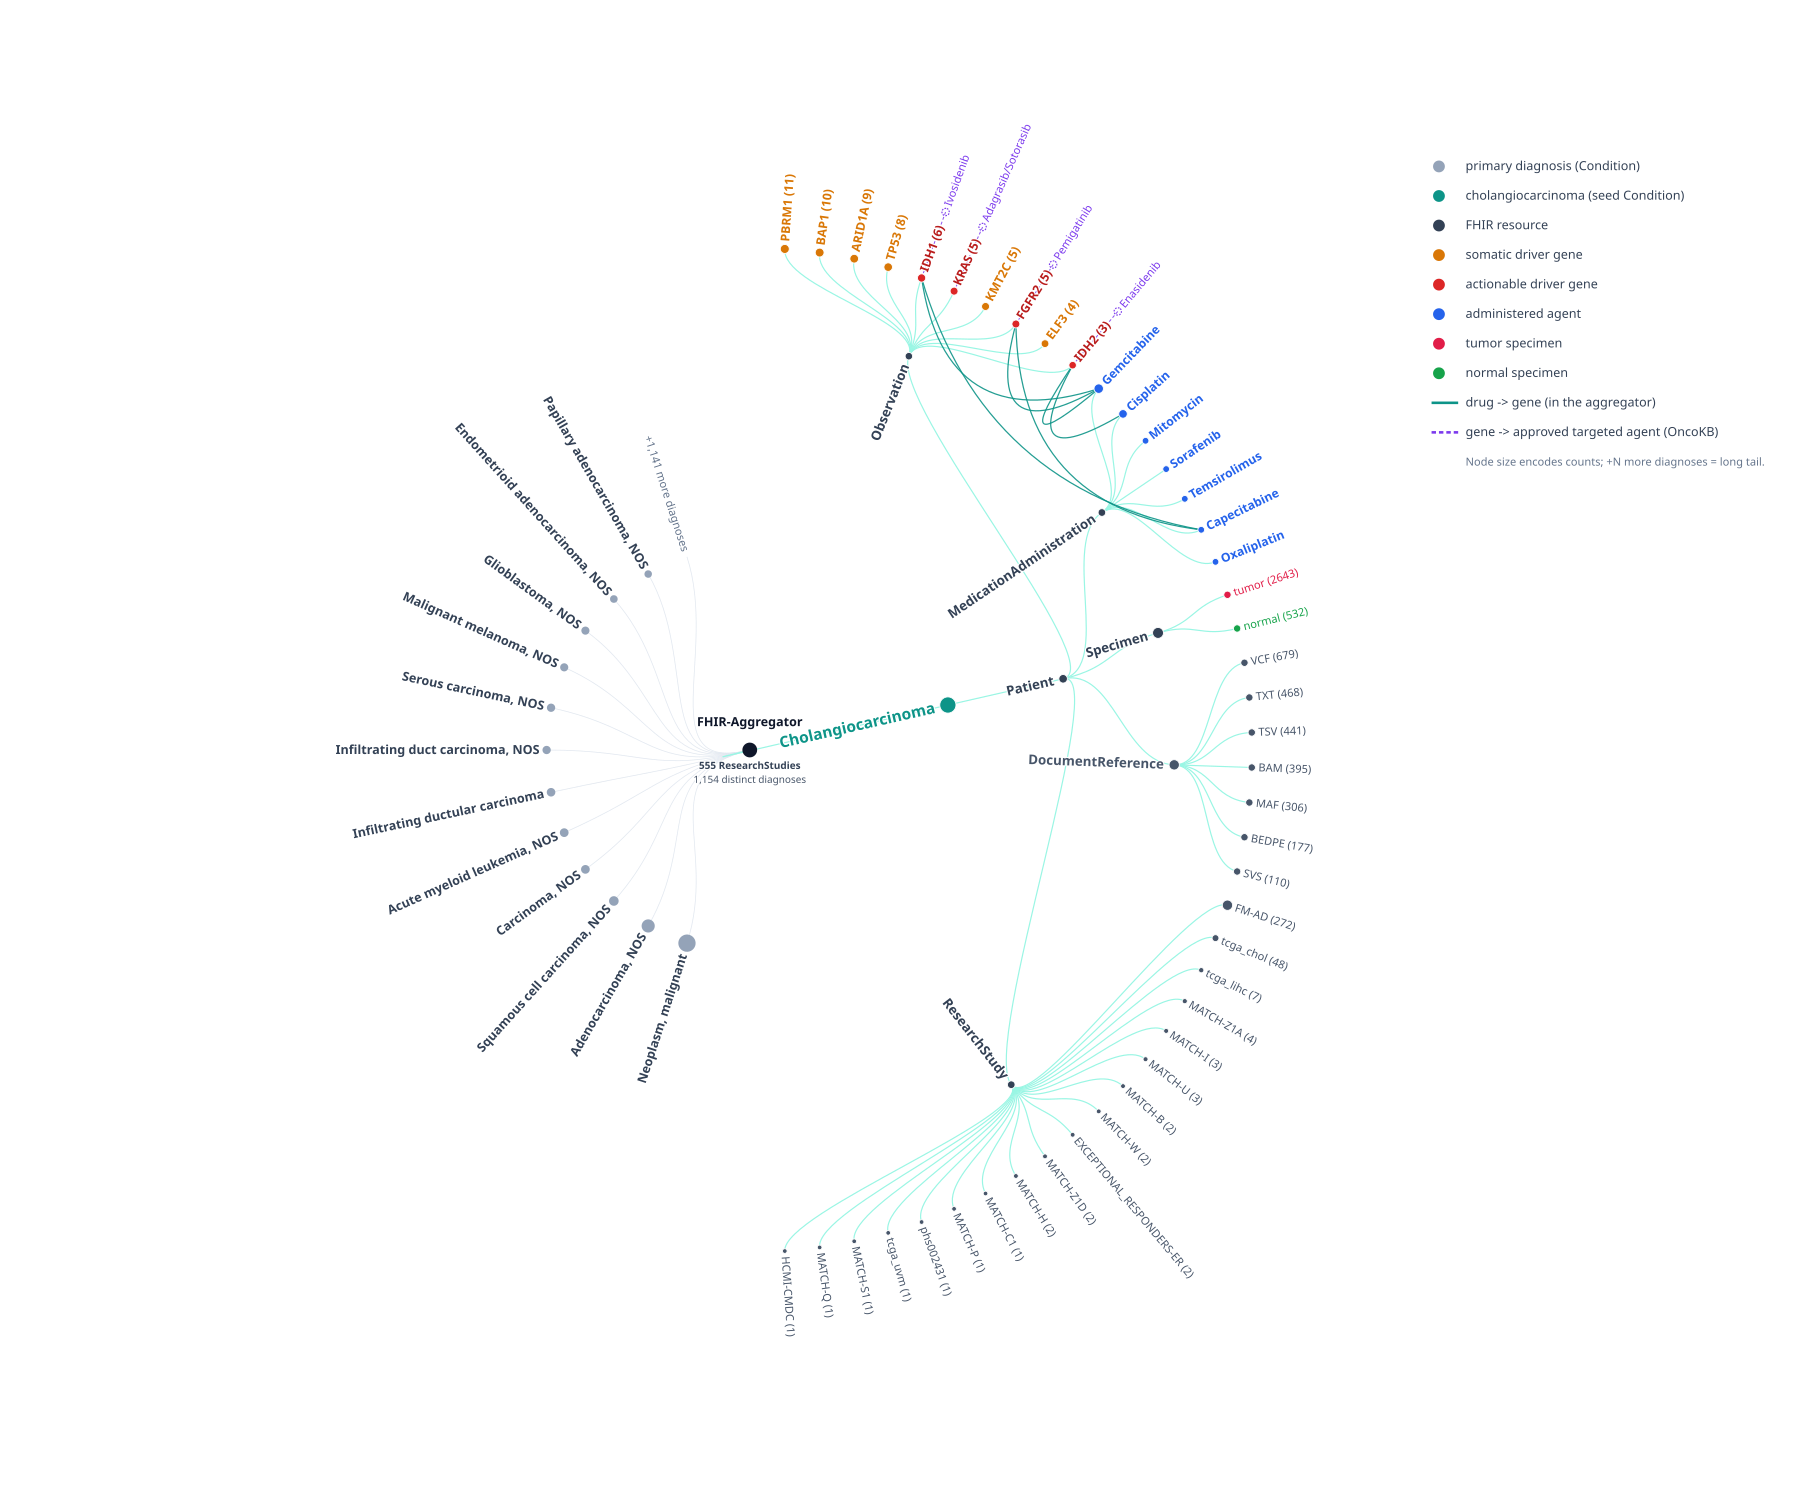

combined radial: studies=18 genes=10 agents=7 | specimens=3175 | bridged file types=7


In [13]:
import json, time, math, html, os, urllib.request, urllib.parse, urllib.error
from collections import Counter, defaultdict
from IPython.display import SVG, display
FHIR_BASE=os.environ.get("FHIR_BASE","https://google-fhir.fhir-aggregator.org").rstrip("/")
FIG_PX=1500   # <-- change to resize the figure
def _get(u,tries=4,timeout=120):
    last=None
    for k in range(tries):
        try: return json.loads(urllib.request.urlopen(urllib.request.Request(u,headers={"User-Agent":"nb"}),timeout=timeout).read())
        except (urllib.error.URLError,TimeoutError,ConnectionError) as e: last=e; time.sleep(2*(k+1))
    raise last
def _pages(u,cap=4000):
    out=[]
    while u and len(out)<cap:
        r=_get(u); out+=r.get("entry",[]); u=next((l["url"] for l in r.get("link",[]) if l.get("relation")=="next"),None)
    return out
def _res(rt): return [json.loads(r) for r in df_raw.loc[df_raw.resource_type==rt,"resource"]]
def _bridge_files():
    # Files live on the GDC molecular Patient, joined to the clinical cohort by the shared submitter
    # barcode (CDA submitter_id == GDC case_submitter_id). Inventory from the bridged TCGA-CHOL study.
    st=_get(f"{FHIR_BASE}/ResearchStudy?identifier=https://gdc.cancer.gov/project|TCGA-CHOL&_count=1")
    if not st.get("entry"): return []
    sid=st["entry"][0]["resource"]["id"]
    pats=[e["resource"].get("individual",{}).get("reference") for e in _pages(f"{FHIR_BASE}/ResearchSubject?study=ResearchStudy/{sid}&_elements=individual&_count=1000") if e["resource"].get("individual")]
    ft=Counter()
    for i in range(0,len(pats),40):
        q=urllib.parse.quote(",".join(p for p in pats[i:i+40] if p),safe=",/")
        for e in _pages(f"{FHIR_BASE}/DocumentReference?subject={q}&_count=1000&_elements=type"):
            ft[e["resource"].get("type",{}).get("coding",[{}])[0].get("display","?")]+=1
    return ft.most_common(7)

CCA_DRIVERS={"FGFR2","IDH1","IDH2","BAP1","ARID1A","ARID2","PBRM1","TP53","KRAS","SMAD4","ERBB2","BRAF","PIK3CA","CDKN2A","ELF3","PTEN","MET","NF1","KMT2C","KMT2D"}
# TARGETS provided by the OncoKB overlay cell above
ACTIONABLE=set(TARGETS)

# ---- extract from df_raw ----
title={f"ResearchStudy/{s['id']}":(s.get('title') or s['id']) for s in _res("ResearchStudy")}
spat=defaultdict(set)
for rs in _res("ResearchSubject"):
    st=(rs.get("study") or {}).get("reference"); ind=(rs.get("individual") or {}).get("reference")
    if st and ind: spat[st].add(ind)
study_ct=Counter({s:len(p) for s,p in spat.items()}); study_name={s:title.get(s,s.split("/")[-1]) for s in study_ct}
pat_genes=defaultdict(set); gene_recur=Counter()
for o in _res("Observation"):
    pid=(o.get("subject",{}).get("reference","") or "").replace("Patient/","")
    for c in o.get("component",[]):
        cc=c.get("code",{}).get("coding",[{}])[0]
        if (cc.get("display") or cc.get("code"))=="hugo_symbol" and c.get("valueString") in CCA_DRIVERS:
            pat_genes[pid].add(c["valueString"])
for pid,gs in pat_genes.items():
    for g in gs: gene_recur[g]+=1
def _agent(r):
    for idn in r.get("identifier",[]):
        if "treatment" in idn.get("system","") and idn.get("value"):
            v=idn["value"]; a=v[37:] if len(v)>37 else v; return a.strip().title() if a else None
pat_drugs=defaultdict(set); agent_ct=Counter()
for m in _res("MedicationAdministration"):
    pid=(m.get("subject",{}).get("reference","") or "").replace("Patient/",""); a=_agent(m)
    if a and a.lower() not in ("unknown","not reported"):
        a=a.replace(" Hydrochloride",""); pat_drugs[pid].add(a); agent_ct[a]+=1
counts=df_raw.resource_type.value_counts().to_dict()
N_PAT=counts.get("Patient",0)
TOP_GENES=[g for g,_ in gene_recur.most_common(10)]; TOP_AGENTS=[a for a,_ in agent_ct.most_common(7)]
# FHIR-native drug<->gene co-occurrence (restrict to shown genes/agents)
cooc=defaultdict(Counter)   # solid edges: drug -> ACTIONABLE driver gene co-occurring in same patient
for pid in set(pat_drugs)&set(pat_genes):
    for d in pat_drugs[pid]:
        if d in TOP_AGENTS:
            for g in pat_genes[pid]:
                if g in TOP_GENES and g in ACTIONABLE: cooc[d][g]+=1

# ---- live: hub + disease ring ----
# hub reads the frozen values (Patient RESOURCE count, as of FREEZE_DATE)
PATH_SYS="http://fhir-aggregator.org/fhir/CodeSystem/vocabulary/path"
vb=_get(f"{FHIR_BASE}/Observation?_count=1000&code=vocabulary&_include=Observation:focus"); dz=Counter(); seen=set()
for e in vb.get("entry",[]):
    r=e.get("resource",{})
    if r.get("resourceType")!="Observation" or r.get("id") in seen: continue
    seen.add(r.get("id"))
    for comp in r.get("component",[]):
        cod=comp.get("code",{}).get("coding",[]); path=next((c.get("code") for c in cod if c.get("system")==PATH_SYS),None)
        if path!="Condition.code": continue
        disp=next((c.get("display") or c.get("code") for c in cod if c.get("system")!=PATH_SYS),None); nn=comp.get("valueInteger")
        if disp and nn: dz[disp]+=nn
dz.pop("Cholangiocarcinoma",None); diseases=[(d,int(c)) for d,c in dz.most_common(12)]; N_DIAG=len(dz)+1

# ---- build tree (agents are leaves; no SMILES) ----
root={"name":"FHIR-Aggregator","type":"root","detail":f"{FROZEN['hub_studies']} ResearchStudies · {FROZEN['hub_diagnoses']:,} distinct diagnoses","children":[]}
for d,c in diseases: root["children"].append({"name":d,"type":"disease","value":int(c)})
tail=N_DIAG-len(diseases)-1
if tail>0: root["children"].append({"name":f"+{tail:,} more diagnoses","type":"tail","value":0})
cc={"name":"Cholangiocarcinoma","type":"focus","value":1,"children":[]}
patient={"name":"Patient","type":"resource","value":N_PAT,"children":[]}
gene_node={}
obs={"name":"Observation","type":"resource","value":max((gene_recur[g] for g in TOP_GENES),default=1),"children":[]}
for g in TOP_GENES:
    nd={"name":f"{g} ({gene_recur[g]})","gene":g,"type":"gene","value":gene_recur[g],"actionable":g in ACTIONABLE}
    gene_node[g]=nd; obs["children"].append(nd)
patient["children"].append(obs)
agent_node={}
med={"name":"MedicationAdministration","type":"resource","value":max((agent_ct[a] for a in TOP_AGENTS),default=1),"children":[]}
for a in TOP_AGENTS:
    nd={"name":a,"agent":a,"type":"agent","value":agent_ct[a]}; agent_node[a]=nd; med["children"].append(nd)
patient["children"].append(med)

# Specimen branch (FHIR-native): tumor / normal
spec=Counter()
for sp in _res("Specimen"):
    t=(sp.get("type",{}).get("coding",[{}])[0].get("display") or "").lower()
    spec["tumor" if ("tumor" in t or "neoplas" in t) else ("normal" if "normal" in t else "other")]+=1
patient["children"].append({"name":"Specimen","type":"resource","value":sum(spec.values()),
    "children":[{"name":f"{k} ({v})","type":"specimen","value":v} for k,v in spec.most_common() if v]})

# DocumentReference branch (files). Reached via the submitter-barcode identity bridge; styled as a
# normal FHIR resource. Inventory from the verified TCGA-CHOL bridge.
FILE_INV=_bridge_files()
patient["children"].append({"name":"DocumentReference","type":"docref","value":sum(n for _,n in FILE_INV),
    "children":[{"name":f"{t} ({n})","type":"file","value":n} for t,n in FILE_INV]})

rs={"name":"ResearchStudy","type":"resource","value":len(study_ct),"children":[]}
for s,c in study_ct.most_common(): rs["children"].append({"name":f"{study_name[s]} ({c})","type":"study","value":c})
patient["children"].append(rs)
cc["children"].append(patient); root["children"].append(cc)

# ---- layout (horizontal two-arc) ----
RING=[0,275,435,575,680,785]; FOCUS_ARC=176.0; CTX_ARC=156.0; FOCUS_C=90.0; CTX_C=270.0
COLOR={"root":"#0f172a","disease":"#94a3b8","tail":"#cbd5e1","focus":"#0d9488","resource":"#334155","study":"#475569","gene":"#d97706","gene_act":"#dc2626","agent":"#2563eb","targeted":"#7c3aed","specimen":"#0891b2","file":"#475569","docref":"#475569"}
def ncolor(n):
    if n["type"]=="gene": return COLOR["gene_act"] if n.get("actionable") else COLOR["gene"]
    if n["type"]=="specimen": return "#e11d48" if "tumor" in n["name"] else "#16a34a"   # tumor=rose, normal=green
    return COLOR.get(n["type"],"#64748b")
def nrad(n):
    v=n.get("value") or 0; t=n["type"]
    return {"root":10,"focus":11,"targeted":5,"specimen":5,"file":5,"docref":7}.get(t) or (max(5,5+4*math.sqrt(v)/math.sqrt(9117)) if t=="resource" else max(2.8,3+4*math.sqrt(v)/math.sqrt(272)) if t=="study" else max(2.5,3+6*math.sqrt(v)/math.sqrt(20000)) if t=="disease" else max(2.8,4+5*math.sqrt(v)/math.sqrt(60)) if t in("gene","agent") else 4)
def layout(root):
    leaves=[]
    def collect(n,d=0,f=False):
        n["depth"]=d; n["inf"]=f or n["type"]=="focus"; ch=n.get("children") or []
        if not ch: leaves.append(n)
        for c in ch: collect(c,d+1,n["inf"])
    collect(root)
    def place(lst,center,arc):
        if not lst: return
        st=math.radians(center-arc/2); sp=math.radians(arc)
        for i,lf in enumerate(lst): lf["angle"]=st+sp*(i+0.5)/len(lst)
    place([l for l in leaves if l["inf"]],FOCUS_C,FOCUS_ARC); place([l for l in leaves if not l["inf"]],CTX_C,CTX_ARC)
    def asg(n):
        ch=n.get("children") or []
        if ch:
            for c in ch: asg(c)
            n["angle"]=sum(c["angle"] for c in ch)/len(ch)
        r=RING[min(n["depth"],len(RING)-1)]; n["r"]=r; n["x"]=r*math.cos(n["angle"]-math.pi/2); n["y"]=r*math.sin(n["angle"]-math.pi/2)
    asg(root)
layout(root)
def pol(a,r): return (r*math.cos(a-math.pi/2), r*math.sin(a-math.pi/2))

# ---- targeted-agent overlay nodes: place just outward from each actionable gene ----
targeted=[]
for g in TOP_GENES:
    if g in TARGETS:
        gn=gene_node[g]; a=gn["angle"]; r=gn["r"]+95
        tn={"name":TARGETS[g],"type":"targeted","angle":a,"r":r,"x":r*math.cos(a-math.pi/2),"y":r*math.sin(a-math.pi/2),"gene":g}
        targeted.append(tn)

# ---- edges ----
def link_path(s,t):
    rm=(s["r"]+t["r"])/2
    x0,y0=pol(s["angle"],s["r"]); x3,y3=pol(t["angle"],t["r"]); x1,y1=pol(s["angle"],rm); x2,y2=pol(t["angle"],rm)
    return f"M{x0:.1f},{y0:.1f}C{x1:.1f},{y1:.1f} {x2:.1f},{y2:.1f} {x3:.1f},{y3:.1f}"
def curve(a,b,bow=0.75):
    # quadratic bezier between two positioned nodes, control pulled toward center
    mx,my=(a["x"]+b["x"])/2,(a["y"]+b["y"])/2
    cx,cy=mx*bow,my*bow
    return f"M{a['x']:.1f},{a['y']:.1f}Q{cx:.1f},{cy:.1f} {b['x']:.1f},{b['y']:.1f}"
base_links=[]; nodes=[]
def walk(n):
    nodes.append(n)
    for c in (n.get("children") or []):
        base_links.append((link_path(n,c),"lk-ctx" if c["type"] in ("disease","tail") else "lk-focus")); walk(c)
walk(root)
# solid FHIR-native drug<->gene co-occurrence
cooc_edges=[]
for d,gc in cooc.items():
    for g,nn in gc.items():
        if d in agent_node and g in gene_node:
            cooc_edges.append((curve(agent_node[d],gene_node[g]), nn, g in ACTIONABLE))
# dotted external gene->targeted
tgt_edges=[curve(gene_node[t['gene']],t,bow=1.0) for t in targeted]

# ---- render ----
parts=[]
allnodes=nodes+targeted
for n in allnodes:
    if n["type"]=="root": continue
    deg=math.degrees(n["angle"])-90; flip=90<(deg%360)<270; col=ncolor(n); r=nrad(n)
    if n["type"] in ("disease","tail"): mk=f'<circle r="{r:.1f}" fill="{col}"/>' if n["type"]=="disease" else ""
    elif n["type"]=="targeted": mk=f'<circle r="{r:.1f}" fill="none" stroke="{col}" stroke-width="1.6" stroke-dasharray="2.2,1.8"/>'
    else: mk=f'<circle r="{r:.1f}" fill="{col}" stroke="#fff" stroke-width="1.2"/>'
    leaf=(not n.get("children")) or n["type"] in ("agent","targeted","specimen","file"); rot=deg+180 if flip else deg
    if leaf: anc,off=("end" if flip else "start"),(-(r+4) if flip else (r+4))
    else: anc,off=("start" if flip else "end"),((r+7) if flip else -(r+7))
    fs={"focus":21,"resource":18,"disease":17,"tail":15,"gene":16.5,"agent":16.5,"study":15,"targeted":15,"specimen":15,"file":15,"docref":18}.get(n["type"],15)
    wt=700 if n["type"] in ("focus","resource","docref") else 600 if n["type"] in ("gene","agent","disease") else 400
    lc="#b91c1c" if (n["type"]=="gene" and n.get("actionable")) else ("#7c3aed" if n["type"]=="targeted" else ("#334155" if n["type"]=="disease" else ("#64748b" if n["type"]=="tail" else col)))
    lab=f'<text transform="rotate({rot:.1f}) translate({off:.1f},0)" text-anchor="{anc}" dy="0.32em" font-size="{fs}" font-weight="{wt}" fill="{lc}">{html.escape(n["name"])}</text>'
    parts.append(f'<g transform="translate({n["x"]:.1f},{n["y"]:.1f}) rotate({deg:.1f})">{mk}<g transform="rotate({-deg:.1f})">{lab}</g></g>')
d0,d1=(root["detail"].split(" · ")+["",""])[:2]
center=f'<g><circle r="10" fill="{COLOR["root"]}"/><text dy="-1.9em" text-anchor="middle" font-size="17" font-weight="800" fill="{COLOR["root"]}">FHIR-Aggregator</text><text dy="1.9em" text-anchor="middle" font-size="13.5" font-weight="600" fill="#334155">{d0}</text><text dy="3.3em" text-anchor="middle" font-size="13.5" fill="#475569">{d1}</text></g>'
R=RING[-1]+230
style='<style>text{paint-order:stroke;stroke:#fff;stroke-width:3px;stroke-linejoin:round}.lk-ctx{fill:none;stroke:#e2e8f0;stroke-width:1}.lk-focus{fill:none;stroke:#99f6e4;stroke-width:1.6}.cooc{fill:none;stroke:#0d9488;stroke-opacity:.55}.cooc-act{fill:none;stroke:#0d9488;stroke-opacity:.9}.tgt{fill:none;stroke:#7c3aed;stroke-width:1.4;stroke-dasharray:4,3;opacity:.85}</style>'
base_svg="".join(f'<path d="{d}" class="{c}"/>' for d,c in base_links)
_cs=[]
for d,nn,act in cooc_edges:
    cls="cooc-act" if act else "cooc"
    _cs.append(f'<path d="{d}" class="{cls}" stroke-width="{1.0+0.7*nn:.1f}"/>')
cooc_svg="".join(_cs)
tgt_svg="".join(f'<path d="{d}" class="tgt"/>' for d in tgt_edges)
# ---- legend (bottom-right; graph flush-left; no title/divider) ----
LEG_W=400
_lx=R+40-132; _y0=-R+230; _lh=40; _tx=_lx+46
_rows=[("node","#94a3b8","primary diagnosis (Condition)"),
       ("node","#0d9488","cholangiocarcinoma (seed Condition)"),
       ("node","#334155","FHIR resource"),
       ("node","#d97706","somatic driver gene"),
       ("node","#dc2626","actionable driver gene"),
       ("node","#2563eb","administered agent"),
       ("node","#e11d48","tumor specimen"),
       ("node","#16a34a","normal specimen"),
       ("solid","#0d9488","drug -> gene (in the aggregator)"),
       ("dotted","#7c3aed","gene -> approved targeted agent (OncoKB)")]
_LG=[]
for _i,(_k,_c,_lab) in enumerate(_rows):
    _y=_y0+_i*_lh
    if _k=="node":
        _mk=f'<circle cx="{_lx+10}" cy="{_y-5}" r="8" fill="{_c}"/>'
    else:
        _d=' stroke-dasharray="6,4"' if _k=="dotted" else ''
        _mk=f'<line x1="{_lx}" y1="{_y-5}" x2="{_lx+36}" y2="{_y-5}" stroke="{_c}" stroke-width="3.5"{_d}/>'
    _LG.append(f'{_mk}<text x="{_tx}" y="{_y}" font-size="17" fill="#334155">{html.escape(_lab)}</text>')
_LG.append(f'<text x="{_tx}" y="{_y0+len(_rows)*_lh}" font-size="15" fill="#64748b">Node size encodes counts; +N more diagnoses = long tail.</text>')
legend_svg="".join(_LG)
svg=f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="{-R} {-R} {2*R+LEG_W} {2*R}" width="{int(FIG_PX*(2*R+LEG_W)/(2*R))}" height="{FIG_PX}" style="font-family:system-ui">{style}<g>{base_svg}</g><g>{cooc_svg}</g><g>{tgt_svg}</g><g>{"".join(parts)}</g>{center}<g>{legend_svg}</g></svg>'
display(SVG(svg))
open("fhir_aggregator_cholangiocarcinoma_specimen_files.html","w").write("<!doctype html><meta charset=utf-8>"+svg)
print("combined radial: studies=%d genes=%d agents=%d | specimens=%d | bridged file types=%d"%(len(study_ct),len(TOP_GENES),len(TOP_AGENTS),sum(v for _,v in [(0,0)]) or counts.get("Specimen",0),len(FILE_INV)))

## Cohort summary

Patients, specimens, source studies, sex, and variant classes for the resolved cohort.

extracting datasets for summary plots...
final dataset: 411 patients


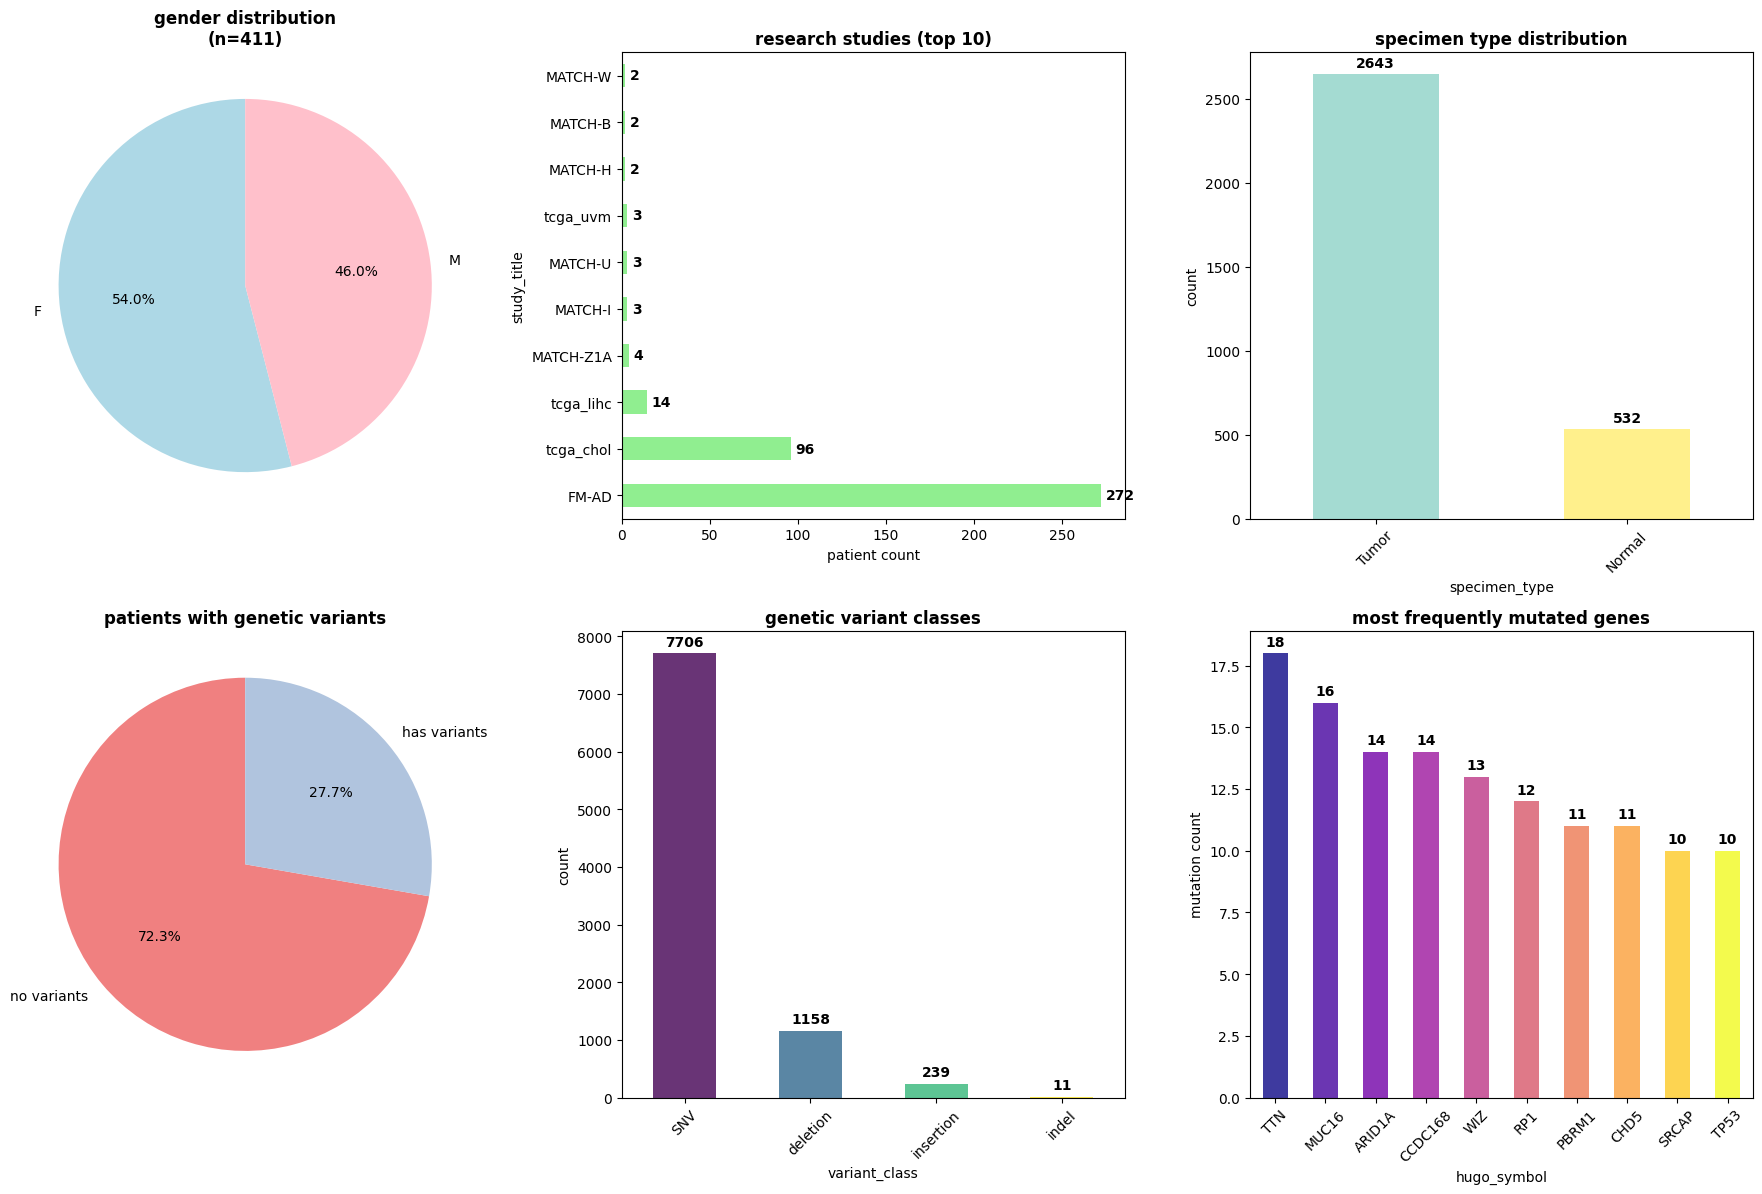


dataset summary:
patients: 354
specimens: 3175 (354 patients)
genetic variants: 9114 (57 patients)
research studies: 18
patient-study assignments: 411
sex: {'F': 191, 'M': 163}
specimen types: {'Tumor': 2643, 'Normal': 532}
variant classes: {'SNV': 7706, 'deletion': 1158, 'insertion': 239, 'indel': 11}


In [14]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

# create resource_dfs from df_raw
resource_dfs = {}
for resource_type in df_raw['resource_type'].unique():
    resource_dfs[resource_type] = df_raw[df_raw['resource_type'] == resource_type].copy()

# extract and create clean datasets
print("extracting datasets for summary plots...")

# 1. patient demographics
patients = []
df_patient = resource_dfs['Patient']
for i, row in df_patient.iterrows():
    try:
        patient_json = json.loads(row['resource'])
        patient_data = {'patient_id': patient_json.get('id')}

        if 'extension' in patient_json:
            for ext in patient_json['extension']:
                if 'url' in ext:
                    if 'us-core-birthsex' in ext['url']:
                        patient_data['gender'] = ext.get('valueCode')
                    elif 'us-core-race' in ext['url']:
                        patient_data['race'] = ext.get('valueCode', ext.get('valueString'))
                    elif 'us-core-ethnicity' in ext['url']:
                        patient_data['ethnicity'] = ext.get('valueCode', ext.get('valueString'))
        patients.append(patient_data)
    except:
        continue
df_patients = pd.DataFrame(patients)

# 2. research studies and patient assignments
studies = []
df_research_study = resource_dfs['ResearchStudy']
for i, row in df_research_study.iterrows():
    try:
        study_json = json.loads(row['resource'])
        studies.append({
            'study_id': study_json.get('id'),
            'study_title': study_json.get('title', 'unknown'),
            'study_status': study_json.get('status', 'unknown')
        })
    except:
        continue
df_studies = pd.DataFrame(studies)

patient_studies = []
df_research_subject = resource_dfs['ResearchSubject']
for i, row in df_research_subject.iterrows():
    try:
        subject_json = json.loads(row['resource'])
        if ('individual' in subject_json and 'reference' in subject_json['individual'] and
            'study' in subject_json and 'reference' in subject_json['study']):
            patient_studies.append({
                'patient_id': subject_json['individual']['reference'].replace('Patient/', ''),
                'study_id': subject_json['study']['reference'].replace('ResearchStudy/', '')
            })
    except:
        continue
df_patient_studies = pd.DataFrame(patient_studies)

# 3. specimens
specimens = []
df_specimen = resource_dfs['Specimen']
for i, row in df_specimen.iterrows():
    try:
        specimen_json = json.loads(row['resource'])
        specimen_data = {
            'specimen_id': specimen_json.get('id'),
            'specimen_type': 'unknown'
        }

        if 'type' in specimen_json and 'coding' in specimen_json['type']:
            if len(specimen_json['type']['coding']) > 0:
                specimen_data['specimen_type'] = specimen_json['type']['coding'][0].get('display', 'unknown')

        if 'subject' in specimen_json and 'reference' in specimen_json['subject']:
            specimen_data['patient_id'] = specimen_json['subject']['reference'].replace('Patient/', '')

        specimens.append(specimen_data)
    except:
        continue
df_specimens = pd.DataFrame(specimens)

# 4. genetic variants
variants = []
df_obs = resource_dfs['Observation']
for i, row in df_obs.iterrows():
    try:
        obs_json = json.loads(row['resource'])

        patient_id = None
        if 'subject' in obs_json and 'reference' in obs_json['subject']:
            patient_id = obs_json['subject']['reference'].replace('Patient/', '')

        if patient_id:
            obs_type = None
            if 'code' in obs_json and 'coding' in obs_json['code']:
                if len(obs_json['code']['coding']) > 0:
                    obs_type = obs_json['code']['coding'][0].get('display')

            if obs_type == 'Performed Genetic Observation Result Mutation Type Code':
                variant_data = {
                    'patient_id': patient_id,
                    'variant_class': None,
                    'hugo_symbol': None,
                    'project': None
                }

                if 'component' in obs_json:
                    for comp in obs_json['component']:
                        if 'code' in comp and 'valueString' in comp:
                            comp_code = None
                            if 'coding' in comp['code'] and len(comp['code']['coding']) > 0:
                                comp_code = comp['code']['coding'][0].get('display')

                            comp_value = comp['valueString']

                            if comp_code == 'variant_class':
                                variant_data['variant_class'] = comp_value
                            elif comp_code == 'hugo_symbol':
                                variant_data['hugo_symbol'] = comp_value
                            elif comp_code == 'project_short_name':
                                variant_data['project'] = comp_value

                variants.append(variant_data)
    except:
        continue
df_variants = pd.DataFrame(variants)

# merge key datasets
df_main = df_patient_studies.merge(df_patients, on='patient_id', how='left')
df_main = df_main.merge(df_studies, on='study_id', how='left')

# add specimen counts
specimen_summary = df_specimens.groupby(['patient_id', 'specimen_type']).size().unstack(fill_value=0)
if 'Normal' in specimen_summary.columns:
    specimen_summary['normal_specimens'] = specimen_summary['Normal']
if 'Tumor' in specimen_summary.columns:
    specimen_summary['tumor_specimens'] = specimen_summary['Tumor']
specimen_summary['total_specimens'] = specimen_summary.sum(axis=1)
df_main = df_main.merge(specimen_summary[['normal_specimens', 'tumor_specimens', 'total_specimens']],
                       on='patient_id', how='left')
df_main[['normal_specimens', 'tumor_specimens', 'total_specimens']] = df_main[['normal_specimens', 'tumor_specimens', 'total_specimens']].fillna(0)

# add variant counts
variant_summary = df_variants.groupby('patient_id').size().reset_index(name='total_variants')
df_main = df_main.merge(variant_summary, on='patient_id', how='left')
df_main['total_variants'] = df_main['total_variants'].fillna(0)

print(f"final dataset: {len(df_main)} patients")

# create summary plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# plot 1: gender distribution
if 'gender' in df_main.columns and df_main['gender'].notna().any():
    gender_counts = df_main['gender'].value_counts()
    colors = ['lightblue', 'pink'][:len(gender_counts)]
    gender_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title(f'gender distribution\n(n={gender_counts.sum()})', fontweight='bold')
    axes[0].set_ylabel('')
else:
    axes[0].text(0.5, 0.5, 'no gender data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('sex distribution')

# plot 2: research studies
if 'study_title' in df_main.columns and df_main['study_title'].notna().any():
    study_counts = df_main['study_title'].value_counts().head(10)
    study_counts.plot(kind='barh', ax=axes[1], color='lightgreen')
    axes[1].set_title('research studies (top 10)', fontweight='bold')
    axes[1].set_xlabel('patient count')
    for i, v in enumerate(study_counts.values):
        axes[1].text(v + max(study_counts.values) * 0.01, i, str(v), va='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'no study data', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('research studies')

# plot 3: specimen types
specimen_data = df_specimens['specimen_type'].value_counts()
if not specimen_data.empty:
    colors = plt.cm.Set3(np.linspace(0, 1, len(specimen_data)))
    specimen_data.plot(kind='bar', ax=axes[2], color=colors, alpha=0.8)
    axes[2].set_title('specimen type distribution', fontweight='bold')
    axes[2].set_ylabel('count')
    axes[2].tick_params(axis='x', rotation=45)
    for i, v in enumerate(specimen_data.values):
        axes[2].text(i, v + max(specimen_data.values) * 0.01, str(v), ha='center', va='bottom', fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'no specimen data', ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('specimen types')

# plot 4: patients with genetic data
if 'total_variants' in df_main.columns:
    genetic_status = (df_main['total_variants'] > 0).value_counts()
    genetic_status.index = ['no variants', 'has variants']
    genetic_status.plot(kind='pie', ax=axes[3], autopct='%1.1f%%',
                       colors=['lightcoral', 'lightsteelblue'], startangle=90)
    axes[3].set_title('patients with genetic variants', fontweight='bold')
    axes[3].set_ylabel('')
else:
    axes[3].text(0.5, 0.5, 'no variant data', ha='center', va='center', transform=axes[3].transAxes)
    axes[3].set_title('genetic variants')

# plot 5: variant classes
if not df_variants.empty and 'variant_class' in df_variants.columns:
    variant_classes = df_variants['variant_class'].value_counts().head(8)
    colors = plt.cm.viridis(np.linspace(0, 1, len(variant_classes)))
    variant_classes.plot(kind='bar', ax=axes[4], color=colors, alpha=0.8)
    axes[4].set_title('genetic variant classes', fontweight='bold')
    axes[4].set_ylabel('count')
    axes[4].tick_params(axis='x', rotation=45)
    for i, v in enumerate(variant_classes.values):
        axes[4].text(i, v + max(variant_classes.values) * 0.01, str(v), ha='center', va='bottom', fontweight='bold')
else:
    axes[4].text(0.5, 0.5, 'no variant classes', ha='center', va='center', transform=axes[4].transAxes)
    axes[4].set_title('variant classes')

# plot 6: top mutated genes
if not df_variants.empty and 'hugo_symbol' in df_variants.columns and df_variants['hugo_symbol'].notna().any():
    top_genes = df_variants['hugo_symbol'].value_counts().head(10)
    colors = plt.cm.plasma(np.linspace(0, 1, len(top_genes)))
    top_genes.plot(kind='bar', ax=axes[5], color=colors, alpha=0.8)
    axes[5].set_title('most frequently mutated genes', fontweight='bold')
    axes[5].set_ylabel('mutation count')
    axes[5].tick_params(axis='x', rotation=45)
    for i, v in enumerate(top_genes.values):
        axes[5].text(i, v + max(top_genes.values) * 0.01, str(v), ha='center', va='bottom', fontweight='bold')
else:
    axes[5].text(0.5, 0.5, 'no gene symbols\navailable', ha='center', va='center', transform=axes[5].transAxes)
    axes[5].set_title('mutated genes')

plt.tight_layout()
plt.show()

# print summary statistics
print(f"\ndataset summary:")
print(f"patients: {len(df_patients)}")
print(f"specimens: {len(df_specimens)} ({df_specimens['patient_id'].nunique()} patients)")
print(f"genetic variants: {len(df_variants)} ({df_variants['patient_id'].nunique()} patients)")
print(f"research studies: {len(df_studies)}")
print(f"patient-study assignments: {len(df_patient_studies)}")

if 'gender' in df_patients.columns:
    print(f"sex: {df_patients['gender'].value_counts().to_dict()}")

if not df_specimens.empty:
    print(f"specimen types: {df_specimens['specimen_type'].value_counts().to_dict()}")

if not df_variants.empty and 'variant_class' in df_variants.columns:
    print(f"variant classes: {df_variants['variant_class'].value_counts().to_dict()}")

## Clinical outcomes: Kaplan-Meier survival

Per-patient overall survival from diagnosis-to-death Observations, stratified by sex, race, and tumour mutation burden, each with a log-rank p. Shown to demonstrate that graph metadata supports stratified survival analysis, not as clinical findings.

survival: 25 unique patients with a diagnosis-to-death observation (median 1.52y)


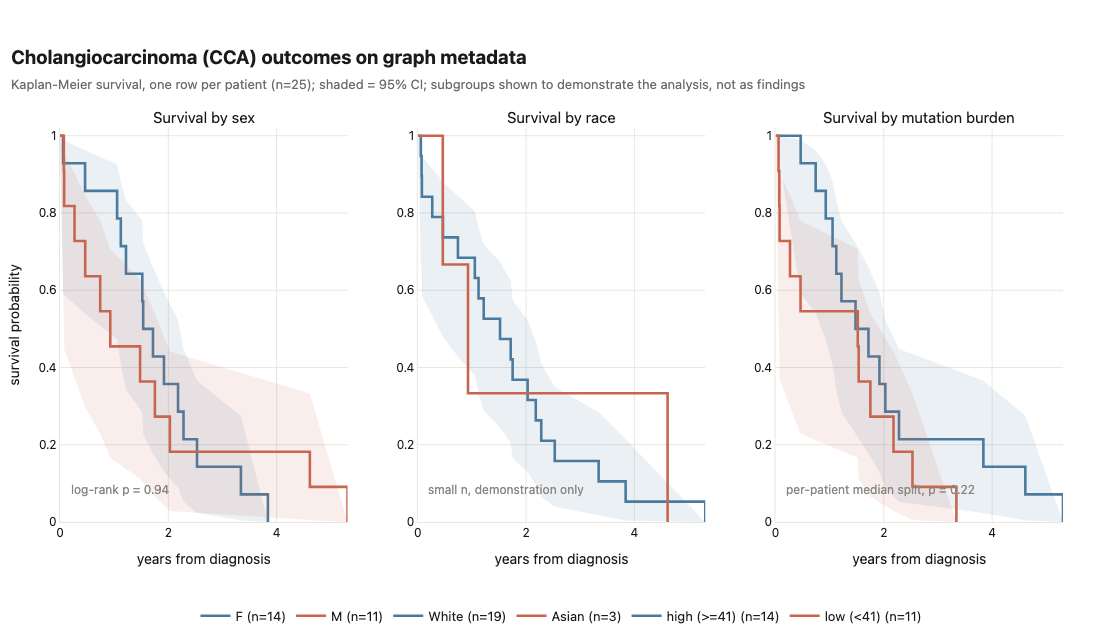

sex log-rank p=0.94 (n.s.) · mutation-burden log-rank p=0.22


In [15]:
import json, numpy as np, pandas as pd
from collections import Counter, defaultdict

# validated dataviz palette
CAT = {"blue":"#2a78d6","aqua":"#1baf7a","yellow":"#eda100","green":"#008300","violet":"#4a3aa7",
       "red":"#e34948","magenta":"#e87ba4","orange":"#eb6834"}
INK,SEC,MUT,GRID,SURF = "#1a1a1a","#6b6a66","#898781","#e8e6df","#ffffff"
FONT = "system-ui, -apple-system, Segoe UI, sans-serif"

def _res(rt): return [json.loads(r) for r in df_raw.loc[df_raw.resource_type==rt, "resource"]]
def _ext(exts, key):
    for e in exts or []:
        if key in e.get("url",""): return e.get("valueCode") or e.get("valueString")

pat = {p["id"]:{"sex":_ext(p.get("extension"),"birthsex"),"race":_ext(p.get("extension"),"us-core-race")} for p in _res("Patient")}
surv, pat_genes, pat_nvar = {}, defaultdict(dict), Counter()
for o in _res("Observation"):
    cd = o.get("code",{}).get("coding",[{}])[0]
    pid = (o.get("subject",{}).get("reference","") or "").replace("Patient/","")
    if cd.get("code")=="NCIT_C156419" or cd.get("display")=="Days between Diagnosis and Death":
        v = o.get("valueQuantity",{}).get("value")
        if pid and v is not None: surv[pid] = v/365.25
    comps = {(c.get("code",{}).get("coding",[{}])[0].get("display") or c.get("code",{}).get("coding",[{}])[0].get("code")):c.get("valueString") for c in o.get("component",[])}
    g, vc = comps.get("hugo_symbol"), comps.get("variant_class")
    if g and pid:
        pat_nvar[pid]+=1; prev=pat_genes[pid].get(g)
        pat_genes[pid][g] = vc if prev is None else ("multiple" if prev!=vc else prev)
# one row per patient (dedup) -> avoids the earlier variant-row inflation
sdf = pd.DataFrame([{"pid":p,"years":surv[p],"event":1,"sex":pat.get(p,{}).get("sex"),
                     "race":pat.get(p,{}).get("race"),"nvar":pat_nvar.get(p,0)} for p in surv])
print(f"survival: {len(sdf)} unique patients with a diagnosis-to-death observation (median {sdf.years.median():.2f}y)")

# ---- Kaplan-Meier survival, per-patient, with log-rank p (plotly) ----
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

def _km(fig, col, groups, pal):
    kmf = KaplanMeierFitter()
    for (lab,d),c in zip(sorted(groups.items(), key=lambda kv:-len(kv[1])), pal):
        kmf.fit(d["years"], d["event"]); sf=kmf.survival_function_.iloc[:,0]
        x=list(sf.index)
        if len(d)>=5:                                        # skip CI band for groups too small to support one
            ci=kmf.confidence_interval_; lo=list(ci.iloc[:,0]); hi=list(ci.iloc[:,1])
            rgba=f"rgba({int(c[1:3],16)},{int(c[3:5],16)},{int(c[5:7],16)},0.11)"
            fig.add_trace(go.Scatter(x=x+x[::-1],y=hi+lo[::-1],fill="toself",fillcolor=rgba,line=dict(width=0),hoverinfo="skip",showlegend=False),row=1,col=col)
        fig.add_trace(go.Scatter(x=x,y=list(sf),mode="lines",line=dict(color=c,width=2.6,shape="hv"),
                      name=f"{lab} (n={len(d)})",hovertemplate=f"{lab}<br>%{{x:.1f}}y · S=%{{y:.2f}}<extra></extra>"),row=1,col=col)

fig = make_subplots(rows=1,cols=3,horizontal_spacing=0.07,
                    subplot_titles=("Survival by sex","Survival by race","Survival by mutation burden"))
fig.update_annotations(font_size=15)
gsex={s:sdf[sdf.sex==s] for s in sdf.sex.dropna().unique() if (sdf.sex==s).sum()>=3}
lr=logrank_test(gsex["F"].years,gsex["M"].years,gsex["F"].event,gsex["M"].event)
_km(fig,1,gsex,["#4a7a9e","#c8654f"])
grace={r:sdf[sdf.race==r] for r in sdf.race.dropna().unique() if (sdf.race==r).sum()>=3}
_km(fig,2,grace,["#4a7a9e","#c8654f","#2f8f83"])
sv=sdf[sdf.nvar>0].copy(); med=sv.nvar.median()
sv["grp"]=np.where(sv.nvar>=med,f"high (>={int(med)})",f"low (<{int(med)})")
lrb=multivariate_logrank_test(sv.years,sv.grp,sv.event)
_km(fig,3,{k:sv[sv.grp==k] for k in sv.grp.unique()},["#4a7a9e","#c8654f"])
for col,txt in zip([1,2,3],[f"log-rank p = {lr.p_value:.2f}","small n, demonstration only",f"per-patient median split, p = {lrb.p_value:.2f}"]):
    fig.add_annotation(text=txt,xref=("x domain" if col==1 else f"x{col} domain"),yref=("y domain" if col==1 else f"y{col} domain"),
                       x=0.03,y=0.06,showarrow=False,font=dict(size=12,color=MUT),xanchor="left")
fig.update_xaxes(title="years from diagnosis",gridcolor=GRID,zeroline=False,title_font=dict(size=14),tickfont=dict(size=12),showline=True,linecolor=GRID)
fig.update_yaxes(range=[0,1.02],gridcolor=GRID,zeroline=False,tickfont=dict(size=12),showline=True,linecolor=GRID)
fig.update_yaxes(title="survival probability",col=1,title_font=dict(size=14))
fig.update_layout(paper_bgcolor=SURF,plot_bgcolor=SURF,font=dict(family=FONT,color=INK,size=15),
                  legend=dict(orientation="h",y=-0.2,x=0.5,xanchor="center",font=dict(size=13)),width=1320,height=628,
                  margin=dict(l=60,r=30,t=128,b=55),
                  title=dict(text=f"<b>Cholangiocarcinoma (CCA) outcomes on graph metadata</b><br><span style='font-size:13px;color:{SEC}'>Kaplan-Meier survival, one row per patient (n={len(sdf)}); shaded = 95% CI; subgroups shown to demonstrate the analysis, not as findings</span>",x=0.01,y=0.90,font=dict(size=19)))
fig.show()
print(f"sex log-rank p={lr.p_value:.2f} (n.s.) · mutation-burden log-rank p={lrb.p_value:.2f}")

## Somatic mutation landscape

An oncoprint of curated cholangiocarcinoma driver genes (grouped by pathway) across the cohort, coloured by variant class, with per-gene mutation frequency and the approved targeted agent for actionable drivers.

survival: 25 unique patients with a diagnosis-to-death observation (median 1.52y)


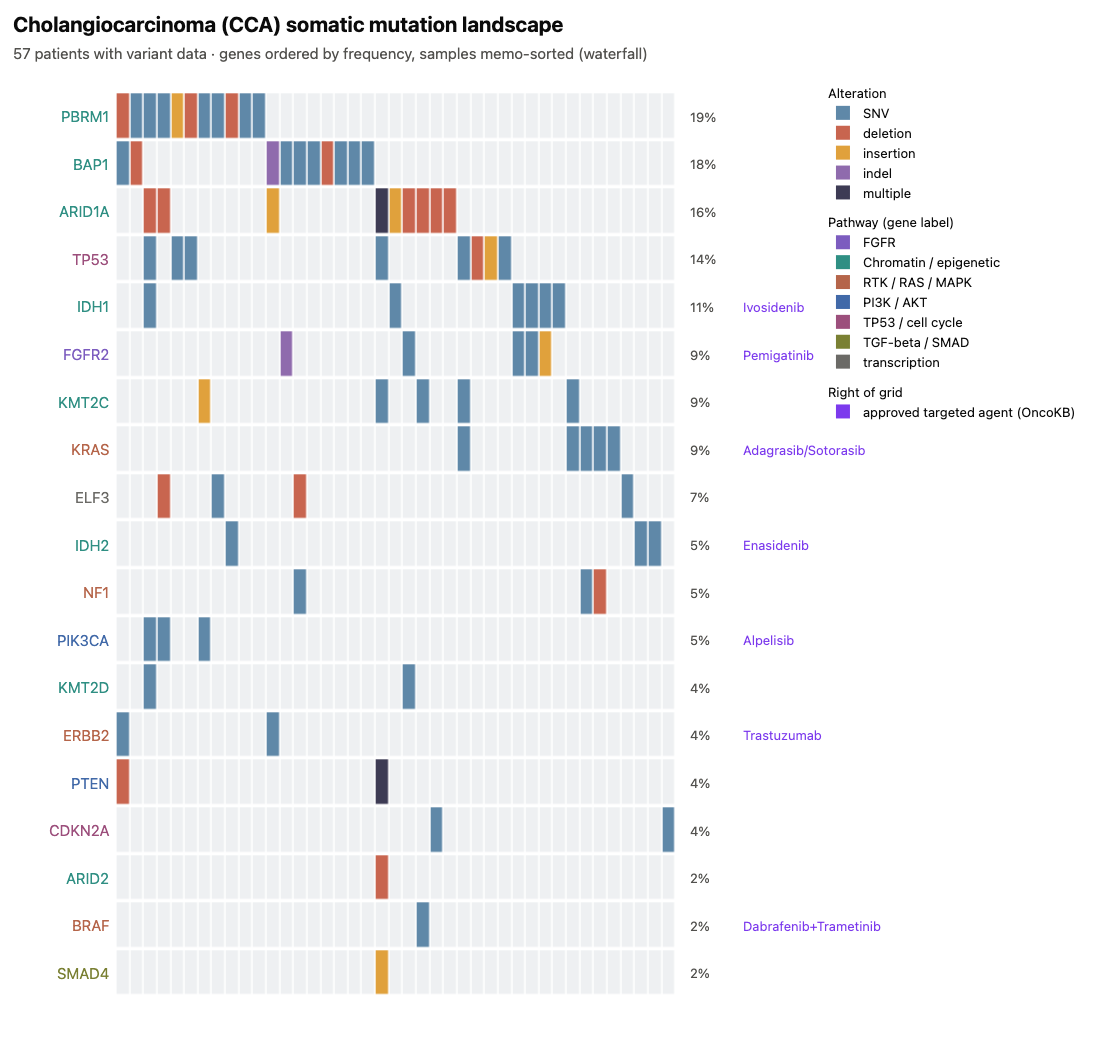


Actionable drivers in this cohort (external targeted-therapy metadata):
gene    patients  freq  targeted agent         link
FGFR2          5    9%  Pemigatinib            https://www.oncokb.org/gene/FGFR2
IDH1           6   11%  Ivosidenib             https://www.oncokb.org/gene/IDH1
IDH2           3    5%  Enasidenib             https://www.oncokb.org/gene/IDH2
KRAS           5    9%  Adagrasib/Sotorasib    https://www.oncokb.org/gene/KRAS
BRAF           1    2%  Dabrafenib+Trametinib  https://www.oncokb.org/gene/BRAF
ERBB2          2    4%  Trastuzumab            https://www.oncokb.org/gene/ERBB2
PIK3CA         3    5%  Alpelisib              https://www.oncokb.org/gene/PIK3CA


In [16]:
import json, numpy as np, pandas as pd
from collections import Counter, defaultdict

# validated dataviz palette
CAT = {"blue":"#2a78d6","aqua":"#1baf7a","yellow":"#eda100","green":"#008300","violet":"#4a3aa7",
       "red":"#e34948","magenta":"#e87ba4","orange":"#eb6834"}
INK,SEC,MUT,GRID,SURF = "#0b0b0b","#52514e","#898781","#e1e0d9","#fcfcfb"
FONT = "system-ui, -apple-system, Segoe UI, sans-serif"

def _res(rt): return [json.loads(r) for r in df_raw.loc[df_raw.resource_type==rt, "resource"]]
def _ext(exts, key):
    for e in exts or []:
        if key in e.get("url",""): return e.get("valueCode") or e.get("valueString")

pat = {p["id"]:{"sex":_ext(p.get("extension"),"birthsex"),"race":_ext(p.get("extension"),"us-core-race")} for p in _res("Patient")}
surv, pat_genes, pat_nvar = {}, defaultdict(dict), Counter()
for o in _res("Observation"):
    cd = o.get("code",{}).get("coding",[{}])[0]
    pid = (o.get("subject",{}).get("reference","") or "").replace("Patient/","")
    if cd.get("code")=="NCIT_C156419" or cd.get("display")=="Days between Diagnosis and Death":
        v = o.get("valueQuantity",{}).get("value")
        if pid and v is not None: surv[pid] = v/365.25
    comps = {(c.get("code",{}).get("coding",[{}])[0].get("display") or c.get("code",{}).get("coding",[{}])[0].get("code")):c.get("valueString") for c in o.get("component",[])}
    g, vc = comps.get("hugo_symbol"), comps.get("variant_class")
    if g and pid:
        pat_nvar[pid]+=1; prev=pat_genes[pid].get(g)
        pat_genes[pid][g] = vc if prev is None else ("multiple" if prev!=vc else prev)
# one row per patient (dedup) -> avoids the earlier variant-row inflation
sdf = pd.DataFrame([{"pid":p,"years":surv[p],"event":1,"sex":pat.get(p,{}).get("sex"),
                     "race":pat.get(p,{}).get("race"),"nvar":pat_nvar.get(p,0)} for p in surv])
print(f"survival: {len(sdf)} unique patients with a diagnosis-to-death observation (median {sdf.years.median():.2f}y)")

# ---- curated driver oncoprint + actionable targeted-therapy table (plotly) ----
import plotly.graph_objects as go
# Cholangiocarcinoma driver genes grouped by the alteration classes established in the CCA genomic
# literature: Banales et al. 2020 (Nat Rev Gastroenterol Hepatol), Nakamura et al. 2015 (Nat Genet),
# Farshidfar et al. 2017 (Cell Rep; TCGA-CHOL). Mutant IDH1/IDH2 act epigenetically in CCA
# (2-hydroxyglutarate -> DNA/histone hypermethylation), so they group with chromatin/epigenetic
# regulators, not "metabolism".
CCA_PATHWAYS={
    "FGFR":                   ["FGFR2"],
    "Chromatin / epigenetic": ["IDH1","IDH2","BAP1","ARID1A","ARID2","PBRM1","KMT2C","KMT2D"],
    "RTK / RAS / MAPK":       ["KRAS","BRAF","ERBB2","NF1","MET"],
    "PI3K / AKT":             ["PIK3CA","PTEN"],
    "TP53 / cell cycle":      ["TP53","CDKN2A"],
    "TGF-beta / SMAD":        ["SMAD4"],
    "transcription":          ["ELF3"],
}
CCA_DRIVERS=[g for gs in CCA_PATHWAYS.values() for g in gs]
# TARGETS provided by the OncoKB overlay cell above
# ---- waterfall oncoprint: genes by frequency, samples memo-sorted; chic palette ----
VC={"SNV":"#5f88a8","deletion":"#c8654f","insertion":"#e0a13c","indel":"#8f6bad","multiple":"#3d3b54"}
EMPTY="#eef0f2"; VIOLET="#7c3aed"; SURF2="#ffffff"
PW={"FGFR":"#7c5cbf","Chromatin / epigenetic":"#2f8f83","RTK / RAS / MAPK":"#b5654a","PI3K / AKT":"#4169a8",
    "TP53 / cell cycle":"#9c4f7c","TGF-beta / SMAD":"#7a8033","transcription":"#6b6a66"}
gene_pw={g:pw for pw,gs in CCA_PATHWAYS.items() for g in gs}
vp=[p for p in pat_genes if pat_genes[p]]; NV=len(vp)
freq={g:sum(1 for p in vp if g in pat_genes[p]) for g in CCA_DRIVERS}
genes=sorted([g for g in CCA_DRIVERS if freq[g]>0], key=lambda g:-freq[g])                 # waterfall rows
cols=sorted([p for p in vp if any(g in pat_genes[p] for g in genes)],
            key=lambda p: tuple(1 if g in pat_genes[p] else 0 for g in genes), reverse=True) # memo-sort columns
rows=genes[::-1]
CODE={None:0,"SNV":1,"deletion":2,"insertion":3,"indel":4,"multiple":5}
z=[[CODE.get(pat_genes[p].get(g)) for p in cols] for g in rows]
txt=[[f"{g} &#183; {p[:8]}<br>{pat_genes[p].get(g) or 'wild-type'}" for p in cols] for g in rows]
disc=[EMPTY,VC["SNV"],VC["deletion"],VC["insertion"],VC["indel"],VC["multiple"]]; nD=len(disc)
cs=[]; [cs.extend([[i/nD,c],[(i+1)/nD,c]]) for i,c in enumerate(disc)]
fig=go.Figure(go.Heatmap(z=z,y=list(range(len(rows))),text=txt,hoverinfo="text",colorscale=cs,
              zmin=-0.5,zmax=5.5,xgap=1.6,ygap=3.4,showscale=False))
fig.update_yaxes(showticklabels=False,showgrid=False,zeroline=False,range=[-0.8,len(rows)-0.2])
fig.update_xaxes(showticklabels=False,showgrid=False,zeroline=False,range=[-7,len(cols)+10])
for i,g in enumerate(rows):
    fig.add_annotation(x=-0.9,y=i,text=g,showarrow=False,xanchor="right",font=dict(size=15,color=PW[gene_pw[g]]))
    fig.add_annotation(x=len(cols)-0.3,y=i,text=f"{100*freq[g]/NV:.0f}%",showarrow=False,xanchor="left",xshift=9,font=dict(size=13,color=SEC))
    if g in TARGETS:
        fig.add_annotation(x=len(cols)-0.3,y=i,text=TARGETS[g],showarrow=False,xanchor="left",xshift=62,font=dict(size=13,color=VIOLET))
for k in ["SNV","deletion","insertion","indel","multiple"]:
    fig.add_trace(go.Scatter(x=[None],y=[None],mode="markers",marker=dict(size=14,color=VC[k],symbol="square"),
                  name=k,legendgroup="a",legendgrouptitle_text="Alteration"))
for pw,c in PW.items():
    if any(gene_pw[g]==pw for g in genes):
        fig.add_trace(go.Scatter(x=[None],y=[None],mode="markers",marker=dict(size=14,color=c,symbol="square"),
                      name=pw,legendgroup="p",legendgrouptitle_text="Pathway (gene label)"))
fig.add_trace(go.Scatter(x=[None],y=[None],mode="markers",marker=dict(size=14,color=VIOLET,symbol="square"),
              name="approved targeted agent (OncoKB)",legendgroup="x",legendgrouptitle_text="Right of grid"))
fig.update_layout(paper_bgcolor=SURF2,plot_bgcolor=SURF2,font=dict(family=FONT,color=INK),
    width=max(1120,len(cols)*27+540),height=len(rows)*44+200,margin=dict(l=28,r=40,t=78,b=40),
    legend=dict(orientation="v",y=1,x=1.005,font=dict(size=13),bgcolor="rgba(0,0,0,0)"),
    title=dict(text=f"<b>Cholangiocarcinoma (CCA) somatic mutation landscape</b><br><span style='font-size:15px;color:{SEC}'>{NV} patients with variant data &#183; genes ordered by frequency, samples memo-sorted (waterfall)</span>",x=0.012,y=0.97,font=dict(size=21)))
fig.show()

# actionable driver -> approved targeted therapy (external: OncoKB)
print("\nActionable drivers in this cohort (external targeted-therapy metadata):")
print(f"{'gene':7}{'patients':>9}{'freq':>6}  {'targeted agent':22} link")
for g in CCA_DRIVERS:
    if g in TARGETS and freq[g]>0:
        print(f"{g:7}{freq[g]:>9}{100*freq[g]/NV:>5.0f}%  {TARGETS[g]:22} https://www.oncokb.org/gene/{g}")

## Paper numbers (paste-ready)

In [17]:
from IPython.display import Markdown, display
b=FROZEN["bridge"]; pt=FROZEN["per_type"]
display(Markdown(f"""
### Paper numbers (frozen {FROZEN['freeze_date']})
- **Total resources:** {FROZEN['total_resources']:,}  ({', '.join(f'{k} {v}' for k,v in sorted(pt.items(), key=lambda x:-x[1]))})
- **Specimens:** {sum(FROZEN['specimen'].values()):,}  ({FROZEN['specimen'].get('tumor',0)} tumor, {FROZEN['specimen'].get('normal',0)} normal)
- **Somatic-variant observations:** {FROZEN['variant_observations']:,} in {FROZEN['variant_patients']} patients
- **Variant classes:** {', '.join(f'{k} {v}' for k,v in FROZEN['variant_classes'].items())}
- **Survival:** n = {FROZEN['survival_n']}, median {FROZEN['survival_median_years']} years  (no comparison significant; sex log-rank p reported in Figure 4)
- **Source studies:** {len(FROZEN['study_titles'])}  ({', '.join(FROZEN['study_titles'])})
- **Aggregator scope:** {FROZEN['hub_studies']} ResearchStudies, {FROZEN['hub_diagnoses']:,} distinct diagnoses
- **Identity bridge (TCGA-CHOL):** {b['tcga_chol_documentreferences']:,} DocumentReferences across {b['tcga_chol_gdc_patients']} patients; join key {b['join_key']}
"""))


### Paper numbers (frozen 2026-07-08)
- **Total resources:** 13,627  (Observation 9195, Specimen 3175, ResearchSubject 411, Condition 389, Patient 354, MedicationAdministration 85, ResearchStudy 18)
- **Specimens:** 3,175  (2643 tumor, 532 normal)
- **Somatic-variant observations:** 9,114 in 57 patients
- **Variant classes:** SNV 7706, deletion 1158, insertion 239, indel 11
- **Survival:** n = 25, median 1.52 years  (no comparison significant; sex log-rank p reported in Figure 4)
- **Source studies:** 18  (EXCEPTIONAL_RESPONDERS-ER, FM-AD, HCMI-CMDC, MATCH-B, MATCH-C1, MATCH-H, MATCH-I, MATCH-P, MATCH-Q, MATCH-S1, MATCH-U, MATCH-W, MATCH-Z1A, MATCH-Z1D, phs002431, tcga_chol, tcga_lihc, tcga_uvm)
- **Aggregator scope:** 555 ResearchStudies, 1,154 distinct diagnoses
- **Identity bridge (TCGA-CHOL):** 3,011 DocumentReferences across 51 patients; join key CDA submitter_id == GDC case_submitter_id
